# COVID-19 Global Trend Analysis

## Comprehensive Analysis of Global Pandemic Trends

This notebook provides a detailed analysis of global COVID-19 trends based on the provided dataset. The analysis covers various aspects of the pandemic including confirmed cases, deaths, recovered cases, active cases, daily trends, mortality rates, recovery rates, growth rates, and WHO region comparisons. Each section includes detailed text explanations and visualizations to understand the pandemic's progression globally.

**Dataset:** COVID-19 full grouped data from January 22, 2020 to July 27, 2020

**Objective:** To analyze global trends and draw conclusions about the effectiveness of lockdown measures based on observed data patterns.

## 1. Import Libraries and Load Data

This section imports all necessary Python libraries for data analysis and visualization, including pandas for data manipulation, numpy for numerical operations, matplotlib and seaborn for visualizations. We also load the COVID-19 dataset from the CSV file located in the final_data folder.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load the dataset
df = pd.read_csv('/Users/ankitkumar/Desktop/final_data/full_grouped.csv')

# Display basic information
print("=" * 60)
print("COVID-19 Dataset Loaded Successfully!")
print("=" * 60)
print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn Names: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")

COVID-19 Dataset Loaded Successfully!

Dataset Shape: 35156 rows, 10 columns

Column Names: ['Date', 'Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases', 'New deaths', 'New recovered', 'WHO Region']

Data Types:
Date                str
Country/Region      str
Confirmed         int64
Deaths            int64
Recovered         int64
Active            int64
New cases         int64
New deaths        int64
New recovered     int64
WHO Region          str
dtype: object


## 2. Data Overview and Preprocessing

This section explores the dataset structure, checks for missing values, converts the date column to datetime format, and prepares data for global aggregation. Understanding the data structure is crucial for accurate analysis.

### Key Steps:
- Display first few rows to understand the data format
- Check for missing values in each column
- Convert Date column to datetime format
- Check the date range of the dataset
- Aggregate data by date for global analysis

In [2]:
# Data Overview and Preprocessing
print("=" * 60)
print("DATA OVERVIEW")
print("=" * 60)

# Display first few rows
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Check for missing values
print("\n" + "=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)
missing_values = df.isnull().sum()
print(f"\nMissing values per column:\n{missing_values}")

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Check date range
print("\n" + "=" * 60)
print("DATE RANGE")
print("=" * 60)
print(f"\nStart Date: {df['Date'].min()}")
print(f"End Date: {df['Date'].max()}")
print(f"Total Days: {(df['Date'].max() - df['Date'].min()).days + 1} days")

# Check unique countries
print("\n" + "=" * 60)
print("COUNTRIES AND REGIONS")
print("=" * 60)
print(f"\nTotal Unique Countries/Regions: {df['Country/Region'].nunique()}")
print(f"\nWHO Regions: {df['WHO Region'].unique().tolist()}")

DATA OVERVIEW

First 5 rows of the dataset:
         Date Country/Region  Confirmed  Deaths  Recovered  Active  New cases  \
0  2020-01-22    Afghanistan          0       0          0       0          0   
1  2020-01-22        Albania          0       0          0       0          0   
2  2020-01-22        Algeria          0       0          0       0          0   
3  2020-01-22        Andorra          0       0          0       0          0   
4  2020-01-22         Angola          0       0          0       0          0   

   New deaths  New recovered             WHO Region  
0           0              0  Eastern Mediterranean  
1           0              0                 Europe  
2           0              0                 Africa  
3           0              0                 Europe  
4           0              0                 Africa  

MISSING VALUES CHECK

Missing values per column:
Date              0
Country/Region    0
Confirmed         0
Deaths            0
Recovered      

In [3]:
# Aggregate data by date for global analysis
global_daily = df.groupby('Date').agg({
    'Confirmed': 'sum',
    'Deaths': 'sum',
    'Recovered': 'sum',
    'Active': 'sum',
    'New cases': 'sum',
    'New deaths': 'sum',
    'New recovered': 'sum'
}).reset_index()

# Sort by date
global_daily = global_daily.sort_values('Date')

print("\n" + "=" * 60)
print("GLOBAL DAILY DATA AGGREGATED")
print("=" * 60)
print(f"\nGlobal data shape: {global_daily.shape}")
print("\nFirst 5 rows of global data:")
print(global_daily.head())
print("\nLast 5 rows of global data:")
print(global_daily.tail())


GLOBAL DAILY DATA AGGREGATED

Global data shape: (188, 8)

First 5 rows of global data:
        Date  Confirmed  Deaths  Recovered  Active  New cases  New deaths  \
0 2020-01-22        555      17         28     510          0           0   
1 2020-01-23        654      18         30     606         99           1   
2 2020-01-24        941      26         36     879        287           8   
3 2020-01-25       1434      42         39    1353        493          16   
4 2020-01-26       2118      56         52    2010        684          14   

   New recovered  
0              0  
1              2  
2              6  
3              3  
4             13  

Last 5 rows of global data:
          Date  Confirmed  Deaths  Recovered   Active  New cases  New deaths  \
183 2020-07-23   15510481  633506    8710969  6166006     282756        9966   
184 2020-07-24   15791645  639650    8939705  6212290     281164        6144   
185 2020-07-25   16047190  644517    9158743  6243930     255545 

## 3. Global Confirmed Cases Trend Analysis

This section analyzes the overall global trend of confirmed COVID-19 cases by aggregating data across all countries. We examine the cumulative growth pattern, key milestones, and the overall progression of the pandemic from its initial outbreak to the latest available data.

### Analysis Highlights:
- **Initial Outbreak (January 2020):** The virus first emerged in China with limited cases
- **Global Spread (February-March 2020):** Rapid spread to Europe and Americas
- **Peak Period (April-June 2020):** Highest case numbers recorded globally
- **Cumulative Growth:** Exponential increase from hundreds to millions of cases

The visualization shows how the confirmed cases evolved over time, with the steepest growth occurring during March and April 2020 when the virus spread globally.

GLOBAL CONFIRMED CASES TREND ANALYSIS

Total Confirmed Cases (End of Period): 16,480,485

--- Key Milestones ---
Reached 1,000 cases on: 2020-01-25
Reached 10,000 cases on: 2020-02-01
Reached 100,000 cases on: 2020-03-06
Reached 1,000,000 cases on: 2020-04-02
Reached 5,000,000 cases on: 2020-05-20
Reached 10,000,000 cases on: 2020-06-28

--- Statistics ---
First confirmed case date: 2020-01-22
Days with confirmed cases: 188
Average daily new cases: 87,771
Maximum daily new cases: 282,756
Date of maximum new cases: 2020-07-23


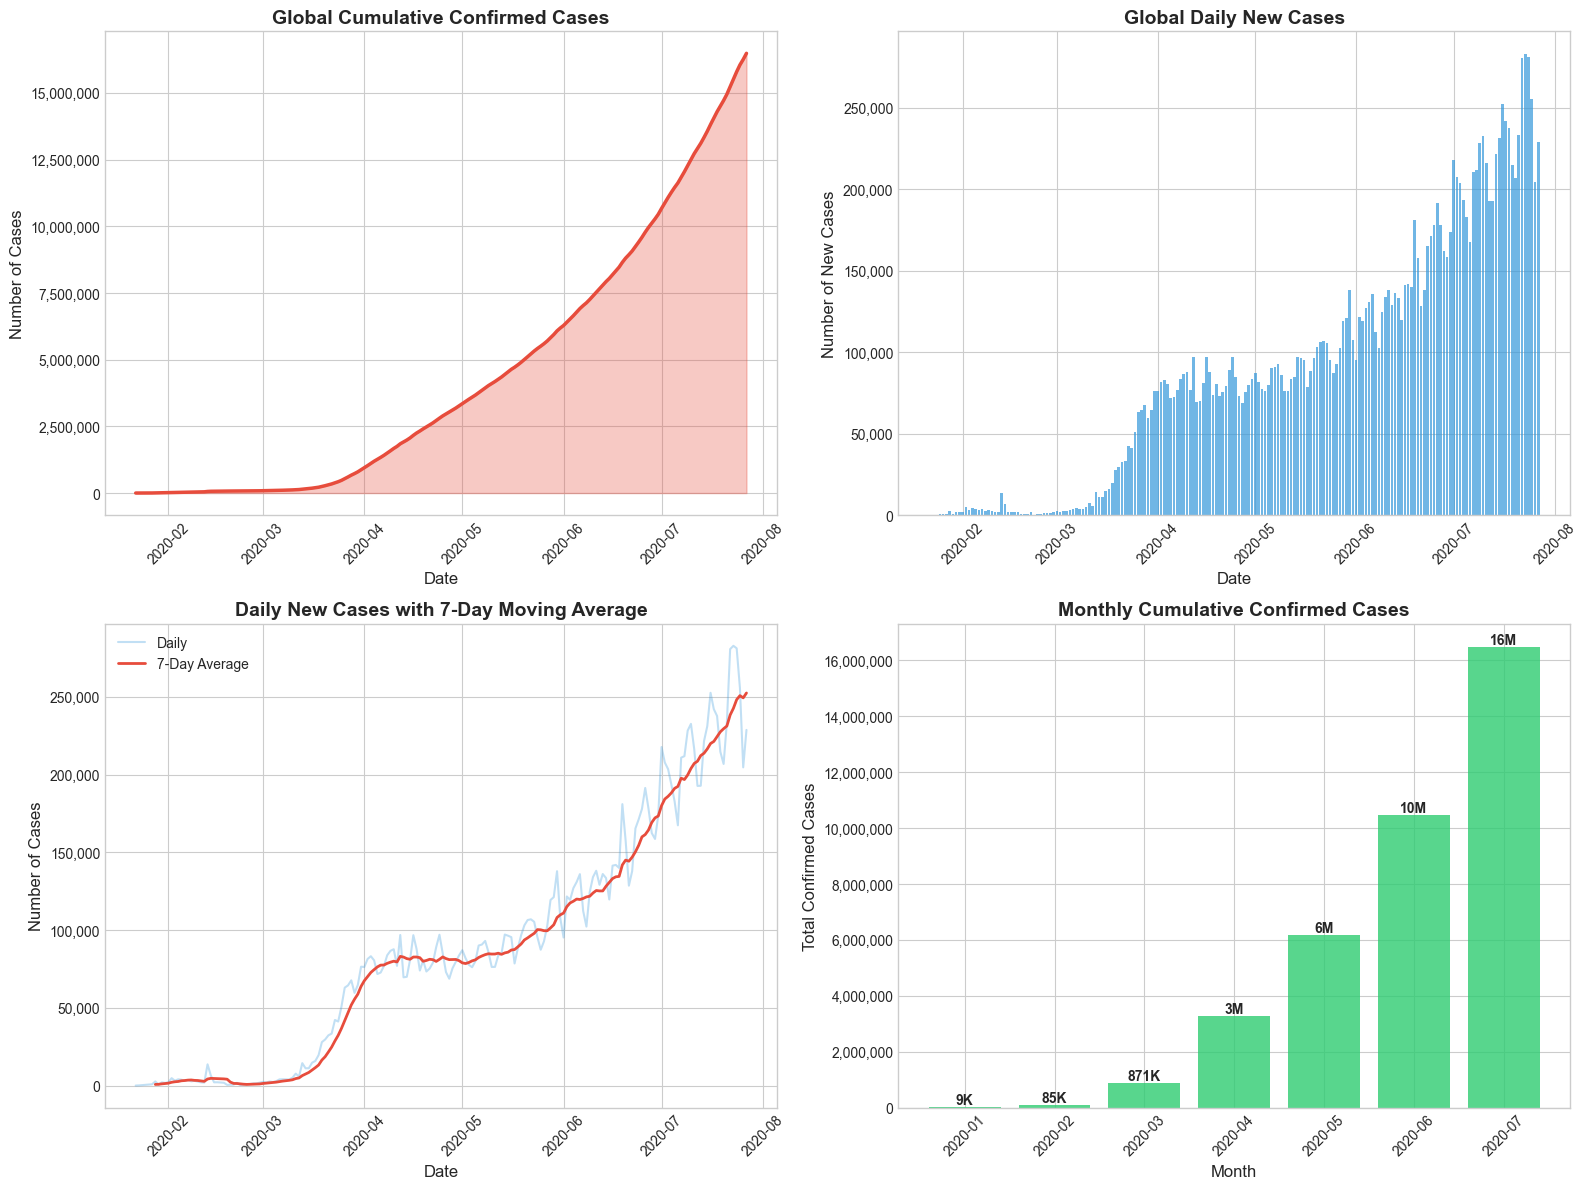


✓ Chart saved: global_confirmed_cases_trend.png


In [4]:
# Global Confirmed Cases Trend Analysis
print("=" * 60)
print("GLOBAL CONFIRMED CASES TREND ANALYSIS")
print("=" * 60)

# Get the latest confirmed cases
latest_confirmed = global_daily['Confirmed'].iloc[-1]
print(f"\nTotal Confirmed Cases (End of Period): {latest_confirmed:,.0f}")

# Key milestones
print("\n--- Key Milestones ---")
milestones = [1000, 10000, 100000, 1000000, 5000000, 10000000]
for milestone in milestones:
    milestone_date = global_daily[global_daily['Confirmed'] >= milestone]['Date'].min()
    if pd.notna(milestone_date):
        print(f"Reached {milestone:,} cases on: {milestone_date.strftime('%Y-%m-%d')}")

# Calculate statistics
print("\n--- Statistics ---")
print(f"First confirmed case date: {global_daily[global_daily['Confirmed'] > 0]['Date'].min().strftime('%Y-%m-%d')}")
print(f"Days with confirmed cases: {(global_daily['Confirmed'] > 0).sum()}")
print(f"Average daily new cases: {global_daily['New cases'].mean():,.0f}")
print(f"Maximum daily new cases: {global_daily['New cases'].max():,.0f}")
print(f"Date of maximum new cases: {global_daily.loc[global_daily['New cases'].idxmax(), 'Date'].strftime('%Y-%m-%d')}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Cumulative Confirmed Cases
ax1 = axes[0, 0]
ax1.plot(global_daily['Date'], global_daily['Confirmed'], color='#e74c3c', linewidth=2.5)
ax1.fill_between(global_daily['Date'], global_daily['Confirmed'], alpha=0.3, color='#e74c3c')
ax1.set_title('Global Cumulative Confirmed Cases', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Number of Cases', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Plot 2: Daily New Cases
ax2 = axes[0, 1]
ax2.bar(global_daily['Date'], global_daily['New cases'], color='#3498db', alpha=0.7)
ax2.set_title('Global Daily New Cases', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Number of New Cases', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Plot 3: Weekly Average New Cases
global_daily['Weekly_Avg'] = global_daily['New cases'].rolling(window=7).mean()
ax3 = axes[1, 0]
ax3.plot(global_daily['Date'], global_daily['New cases'], alpha=0.3, color='#3498db', label='Daily')
ax3.plot(global_daily['Date'], global_daily['Weekly_Avg'], color='#e74c3c', linewidth=2, label='7-Day Average')
ax3.set_title('Daily New Cases with 7-Day Moving Average', fontsize=14, fontweight='bold')
ax3.set_xlabel('Date', fontsize=12)
ax3.set_ylabel('Number of Cases', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
ax3.legend()
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Plot 4: Monthly Confirmed Cases
global_daily['Month'] = global_daily['Date'].dt.to_period('M')
monthly_confirmed = global_daily.groupby('Month')['Confirmed'].last().reset_index()
monthly_confirmed['Month'] = monthly_confirmed['Month'].astype(str)
ax4 = axes[1, 1]
bars = ax4.bar(monthly_confirmed['Month'], monthly_confirmed['Confirmed'], color='#2ecc71', alpha=0.8)
ax4.set_title('Monthly Cumulative Confirmed Cases', fontsize=14, fontweight='bold')
ax4.set_xlabel('Month', fontsize=12)
ax4.set_ylabel('Total Confirmed Cases', fontsize=12)
ax4.tick_params(axis='x', rotation=45)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax4.annotate(f'{int(height/1000000)}M' if height >= 1000000 else f'{int(height/1000)}K',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/ankitkumar/Desktop/final_data/global_confirmed_cases_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Chart saved: global_confirmed_cases_trend.png")

## 4. Global Deaths Trend Analysis

This section analyzes the global mortality trend by aggregating death counts by date. Understanding the death pattern is crucial for assessing the severity of the pandemic and the effectiveness of healthcare interventions.

### Analysis Highlights:
- **Initial Deaths (January 2020):** First deaths reported in China
- **European Surge (March 2020):** Italy, Spain, and UK experienced high death tolls
- **Global Peak (April 2020):** Highest daily death counts recorded globally
- **Gradual Decline (May-June 2020):** Death rates began to decrease in many regions

The analysis reveals that while confirmed cases continued to rise, the death rate showed signs of stabilization and eventual decline, possibly due to improved treatment protocols and better healthcare preparation. The visualization shows the cumulative deaths and daily death counts over time.

GLOBAL DEATHS TREND ANALYSIS

Total Deaths (End of Period): 654,036

--- Key Statistics ---
First death date: 2020-01-22
Average daily new deaths: 3,479
Maximum daily new deaths: 9,966
Date of maximum deaths: 2020-07-23

Case Fatality Rate (CFR): 3.97%


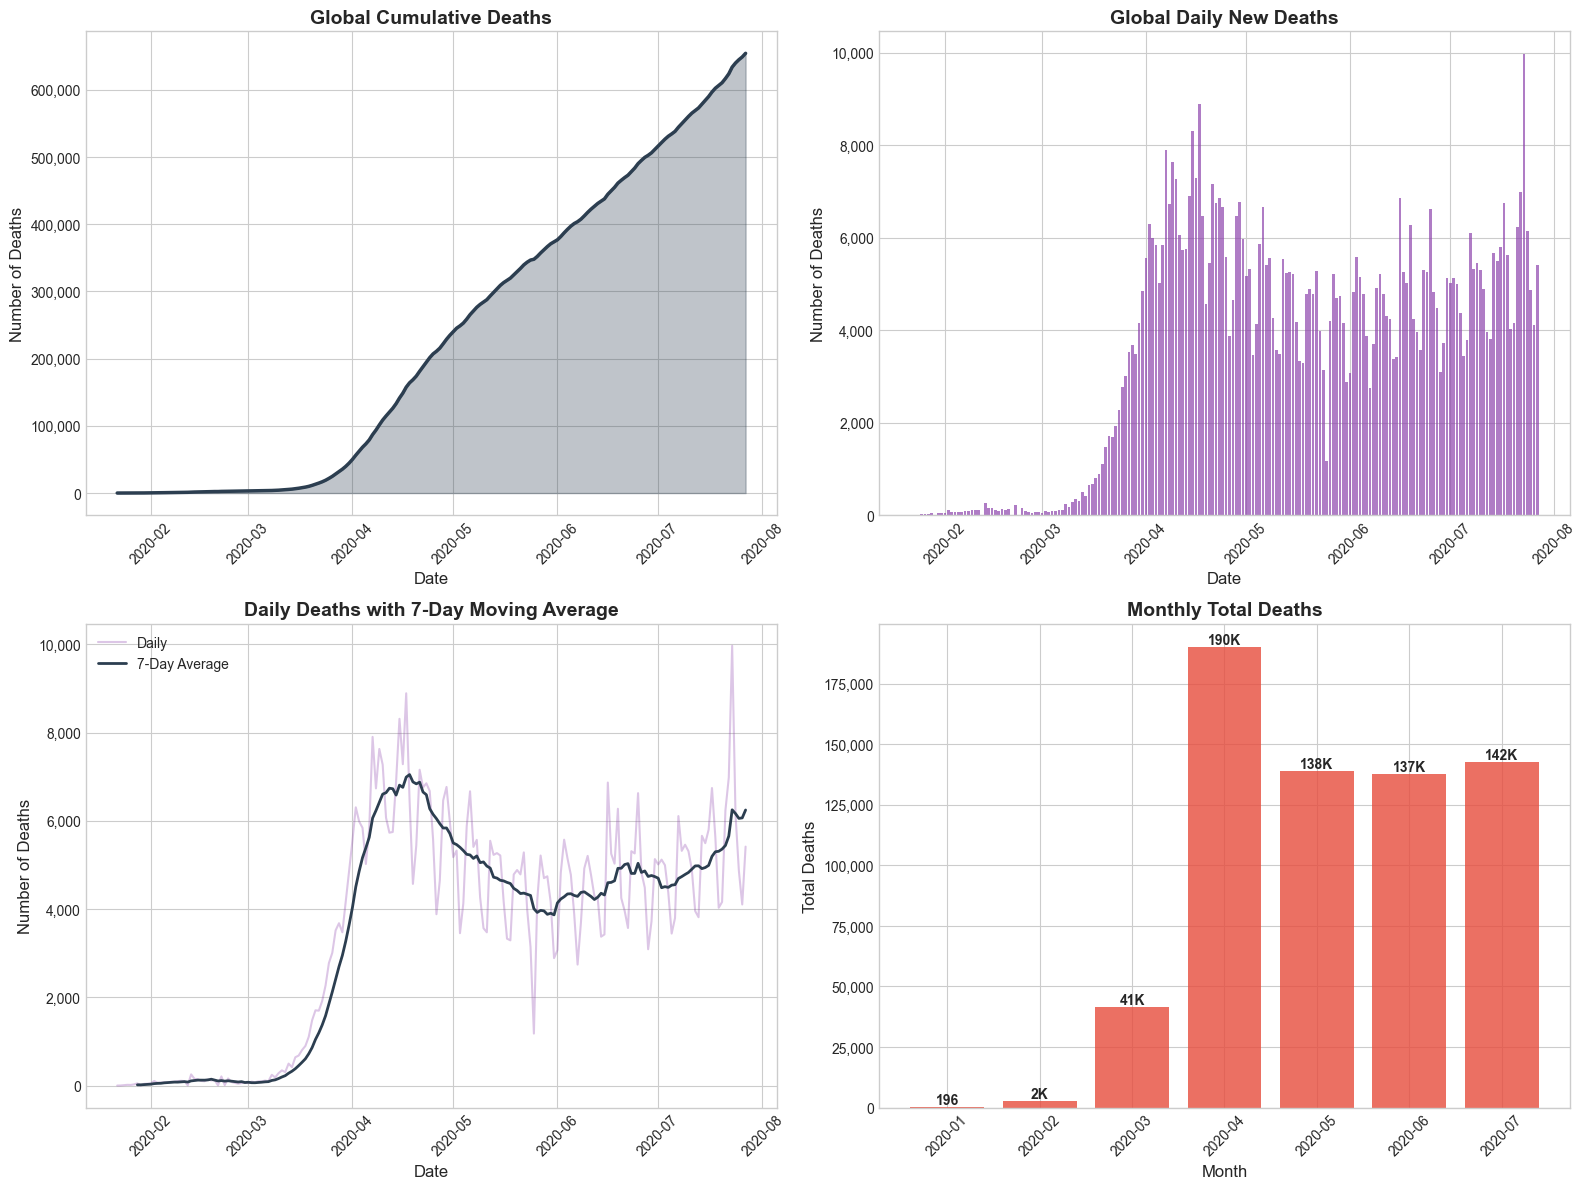


✓ Chart saved: global_deaths_trend.png


In [42]:
# Global Deaths Trend Analysis
print("=" * 60)
print("GLOBAL DEATHS TREND ANALYSIS")
print("=" * 60)

# Get the latest death data
latest_deaths = global_daily['Deaths'].iloc[-1]
print(f"\nTotal Deaths (End of Period): {latest_deaths:,.0f}")

# Key statistics
print("\n--- Key Statistics ---")
print(f"First death date: {global_daily[global_daily['Deaths'] > 0]['Date'].min().strftime('%Y-%m-%d')}")
print(f"Average daily new deaths: {global_daily['New deaths'].mean():,.0f}")
print(f"Maximum daily new deaths: {global_daily['New deaths'].max():,.0f}")
print(f"Date of maximum deaths: {global_daily.loc[global_daily['New deaths'].idxmax(), 'Date'].strftime('%Y-%m-%d')}")

# Case Fatality Rate
cfr = (latest_deaths / latest_confirmed) * 100
print(f"\nCase Fatality Rate (CFR): {cfr:.2f}%")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Cumulative Deaths
ax1 = axes[0, 0]
ax1.plot(global_daily['Date'], global_daily['Deaths'], color='#2c3e50', linewidth=2.5)
ax1.fill_between(global_daily['Date'], global_daily['Deaths'], alpha=0.3, color='#2c3e50')
ax1.set_title('Global Cumulative Deaths', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Number of Deaths', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Plot 2: Daily New Deaths
ax2 = axes[0, 1]
ax2.bar(global_daily['Date'], global_daily['New deaths'], color='#8e44ad', alpha=0.7)
ax2.set_title('Global Daily New Deaths', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Number of Deaths', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Plot 3: Weekly Average Deaths
global_daily['Weekly_Deaths_Avg'] = global_daily['New deaths'].rolling(window=7).mean()
ax3 = axes[1, 0]
ax3.plot(global_daily['Date'], global_daily['New deaths'], alpha=0.3, color='#8e44ad', label='Daily')
ax3.plot(global_daily['Date'], global_daily['Weekly_Deaths_Avg'], color='#2c3e50', linewidth=2, label='7-Day Average')
ax3.set_title('Daily Deaths with 7-Day Moving Average', fontsize=14, fontweight='bold')
ax3.set_xlabel('Date', fontsize=12)
ax3.set_ylabel('Number of Deaths', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
ax3.legend()
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Plot 4: Monthly Deaths
monthly_deaths = global_daily.groupby('Month')['New deaths'].sum().reset_index()
monthly_deaths['Month'] = monthly_deaths['Month'].astype(str)
ax4 = axes[1, 1]
bars = ax4.bar(monthly_deaths['Month'], monthly_deaths['New deaths'], color='#e74c3c', alpha=0.8)
ax4.set_title('Monthly Total Deaths', fontsize=14, fontweight='bold')
ax4.set_xlabel('Month', fontsize=12)
ax4.set_ylabel('Total Deaths', fontsize=12)
ax4.tick_params(axis='x', rotation=45)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax4.annotate(f'{int(height/1000)}K' if height >= 1000 else f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/ankitkumar/Desktop/final_data/global_deaths_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Chart saved: global_deaths_trend.png")

## 5. Global Recovered Cases Trend Analysis

This section analyzes the global recovery trend by aggregating recovered cases by date. Tracking recoveries is essential for understanding the pandemic's outcome and the capacity of healthcare systems to treat patients.

### Analysis Highlights:
- **Early Recoveries (January 2020):** First patients recovered in China
- **Recovery Acceleration (March-April 2020):** As cases increased, recovery numbers also grew significantly
- **Recovery Rate Improvement (May-June 2020):** With better treatment protocols, more patients recovered
- **Cumulative Recovery:** Shows the total number of patients who have recovered from COVID-19

The analysis demonstrates that as the pandemic progressed, healthcare systems learned to treat COVID-19 more effectively, leading to higher recovery rates. The visualization shows the cumulative recovered cases and daily new recoveries over time, highlighting the positive trend of increasing recoveries globally.

GLOBAL RECOVERED CASES TREND ANALYSIS

Total Recovered Cases (End of Period): 9,468,087

--- Key Statistics ---
First recovery date: 2020-01-22
Average daily new recoveries: 50,362
Maximum daily new recoveries: 284,394
Date of maximum recoveries: 2020-07-02

Recovery Rate: 57.45%


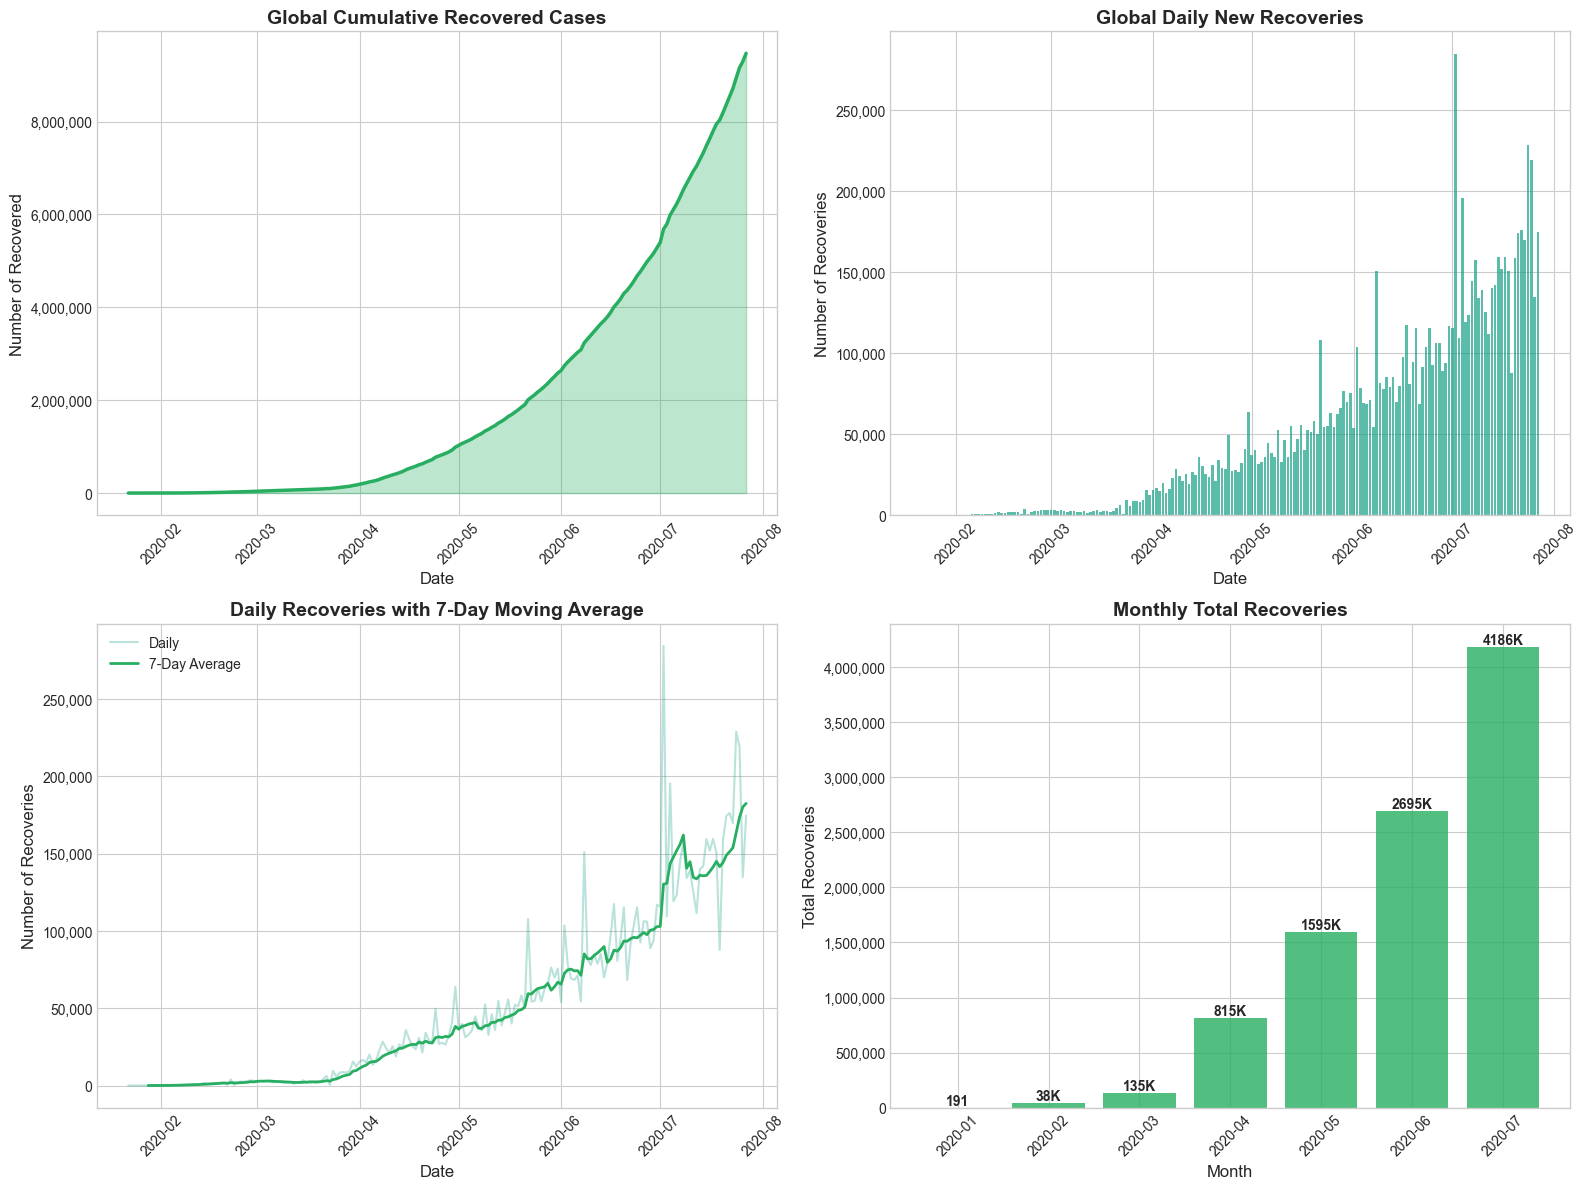


✓ Chart saved: global_recovered_trend.png


In [6]:
# Global Recovered Cases Trend Analysis
print("=" * 60)
print("GLOBAL RECOVERED CASES TREND ANALYSIS")
print("=" * 60)

# Get the latest recovered data
latest_recovered = global_daily['Recovered'].iloc[-1]
print(f"\nTotal Recovered Cases (End of Period): {latest_recovered:,.0f}")

# Key statistics
print("\n--- Key Statistics ---")
print(f"First recovery date: {global_daily[global_daily['Recovered'] > 0]['Date'].min().strftime('%Y-%m-%d')}")
print(f"Average daily new recoveries: {global_daily['New recovered'].mean():,.0f}")
print(f"Maximum daily new recoveries: {global_daily['New recovered'].max():,.0f}")
print(f"Date of maximum recoveries: {global_daily.loc[global_daily['New recovered'].idxmax(), 'Date'].strftime('%Y-%m-%d')}")

# Recovery Rate
recovery_rate = (latest_recovered / latest_confirmed) * 100
print(f"\nRecovery Rate: {recovery_rate:.2f}%")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Cumulative Recovered Cases
ax1 = axes[0, 0]
ax1.plot(global_daily['Date'], global_daily['Recovered'], color='#27ae60', linewidth=2.5)
ax1.fill_between(global_daily['Date'], global_daily['Recovered'], alpha=0.3, color='#27ae60')
ax1.set_title('Global Cumulative Recovered Cases', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Number of Recovered', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Plot 2: Daily New Recoveries
ax2 = axes[0, 1]
ax2.bar(global_daily['Date'], global_daily['New recovered'], color='#16a085', alpha=0.7)
ax2.set_title('Global Daily New Recoveries', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Number of Recoveries', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Plot 3: Weekly Average Recoveries
global_daily['Weekly_Recovered_Avg'] = global_daily['New recovered'].rolling(window=7).mean()
ax3 = axes[1, 0]
ax3.plot(global_daily['Date'], global_daily['New recovered'], alpha=0.3, color='#16a085', label='Daily')
ax3.plot(global_daily['Date'], global_daily['Weekly_Recovered_Avg'], color='#27ae60', linewidth=2, label='7-Day Average')
ax3.set_title('Daily Recoveries with 7-Day Moving Average', fontsize=14, fontweight='bold')
ax3.set_xlabel('Date', fontsize=12)
ax3.set_ylabel('Number of Recoveries', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
ax3.legend()
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Plot 4: Monthly Recoveries
monthly_recovered = global_daily.groupby('Month')['New recovered'].sum().reset_index()
monthly_recovered['Month'] = monthly_recovered['Month'].astype(str)
ax4 = axes[1, 1]
bars = ax4.bar(monthly_recovered['Month'], monthly_recovered['New recovered'], color='#27ae60', alpha=0.8)
ax4.set_title('Monthly Total Recoveries', fontsize=14, fontweight='bold')
ax4.set_xlabel('Month', fontsize=12)
ax4.set_ylabel('Total Recoveries', fontsize=12)
ax4.tick_params(axis='x', rotation=45)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax4.annotate(f'{int(height/1000)}K' if height >= 1000 else f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/ankitkumar/Desktop/final_data/global_recovered_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Chart saved: global_recovered_trend.png")

## 6. Global Active Cases Trend Analysis

This section calculates and visualizes active cases globally (Confirmed - Deaths - Recovered). Active cases represent the current burden of the pandemic - the number of people currently fighting the disease.

### Analysis Highlights:
- **Active Cases Definition:** Current number of confirmed cases minus deaths and recoveries
- **Peak Active Cases (April 2020):** The highest number of active cases occurred during the peak of the pandemic
- **Gradual Decline (May-June 2020):** As recoveries increased and new cases stabilized, active cases began to decrease
- **Healthcare Burden:** Active cases indicate the current strain on healthcare systems

The analysis shows that while total confirmed cases continued to rise, the number of active cases (the currently infected population) showed a more complex pattern. The decline in active cases relative to confirmed cases indicates improving recovery rates and effective containment measures. This is a key indicator of pandemic management success.

GLOBAL ACTIVE CASES TREND ANALYSIS

Total Active Cases (End of Period): 6,358,362

--- Key Statistics ---
Maximum active cases: 6,358,362
Date of maximum active cases: 2020-07-27
Minimum active cases: 510

Active cases as % of confirmed (latest): 38.58%


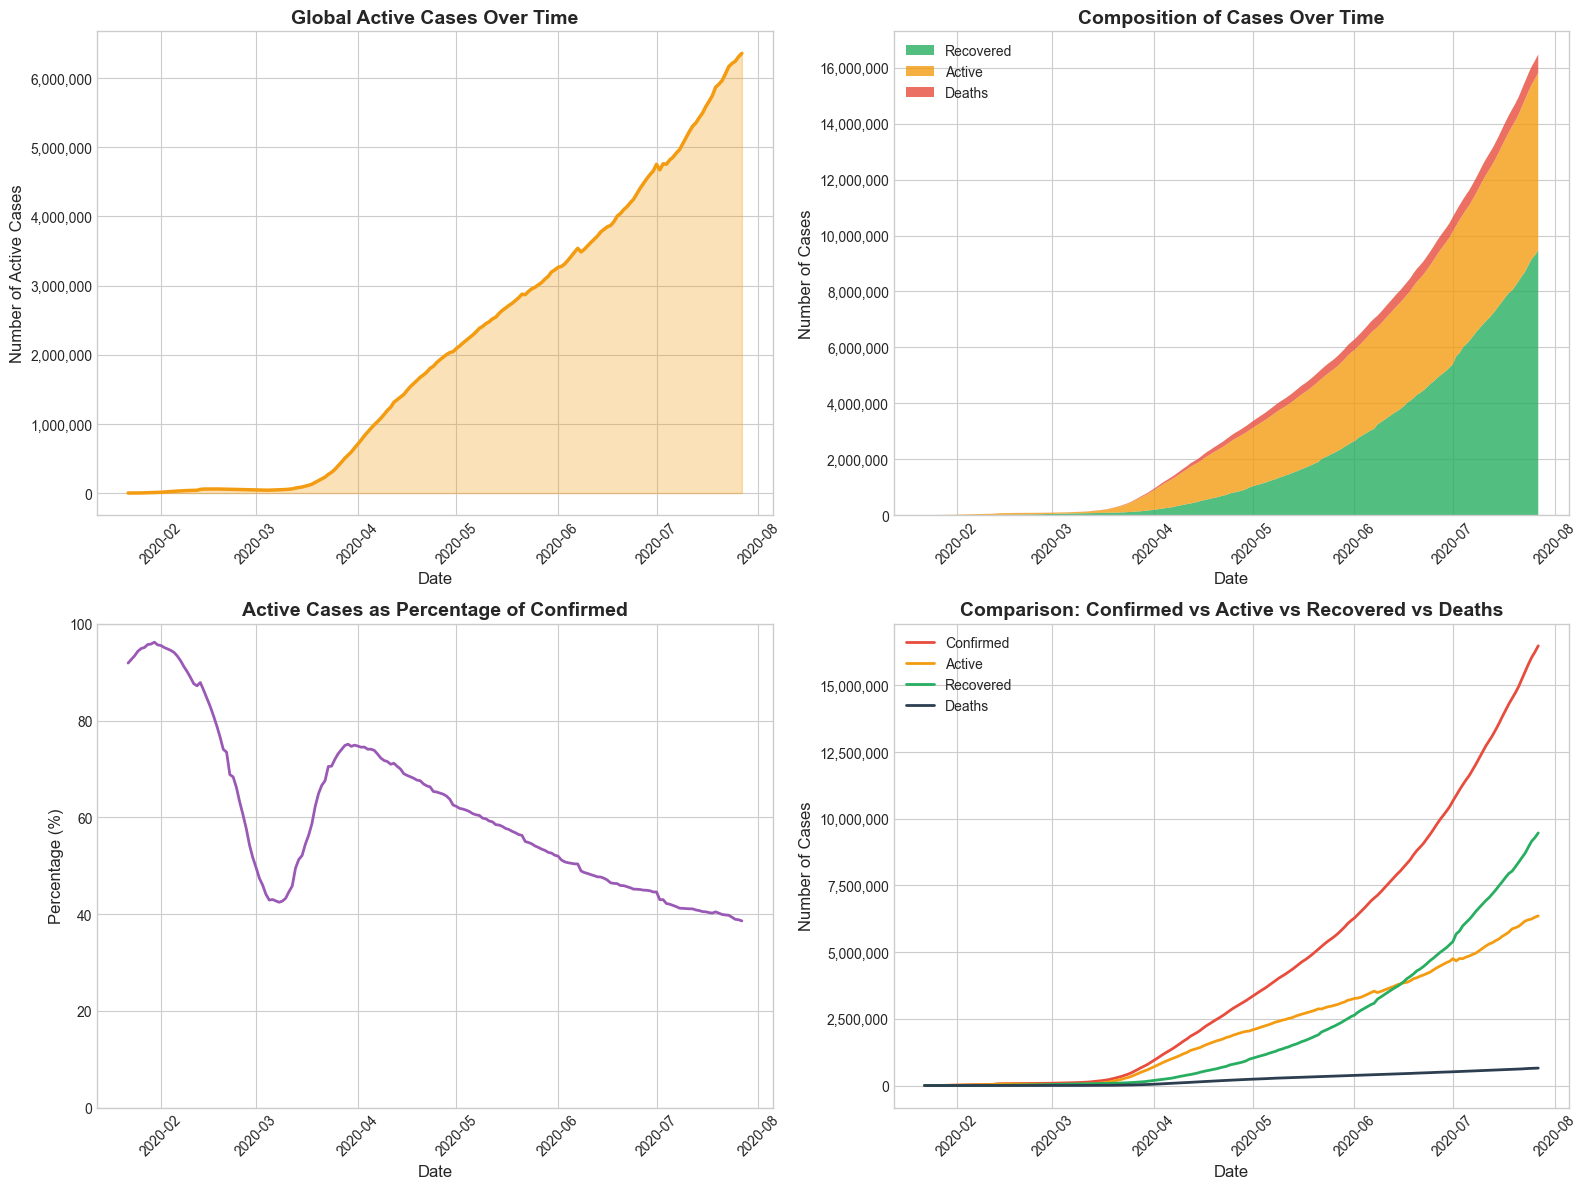


✓ Chart saved: global_active_cases_trend.png


In [7]:
# Global Active Cases Trend Analysis
print("=" * 60)
print("GLOBAL ACTIVE CASES TREND ANALYSIS")
print("=" * 60)

# Get the latest active cases
latest_active = global_daily['Active'].iloc[-1]
print(f"\nTotal Active Cases (End of Period): {latest_active:,.0f}")

# Key statistics
print("\n--- Key Statistics ---")
print(f"Maximum active cases: {global_daily['Active'].max():,.0f}")
print(f"Date of maximum active cases: {global_daily.loc[global_daily['Active'].idxmax(), 'Date'].strftime('%Y-%m-%d')}")
print(f"Minimum active cases: {global_daily['Active'].min():,.0f}")

# Active cases as percentage of confirmed
global_daily['Active_Pct'] = (global_daily['Active'] / global_daily['Confirmed']) * 100
print(f"\nActive cases as % of confirmed (latest): {global_daily['Active_Pct'].iloc[-1]:.2f}%")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Cumulative Active Cases
ax1 = axes[0, 0]
ax1.plot(global_daily['Date'], global_daily['Active'], color='#f39c12', linewidth=2.5)
ax1.fill_between(global_daily['Date'], global_daily['Active'], alpha=0.3, color='#f39c12')
ax1.set_title('Global Active Cases Over Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Number of Active Cases', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Plot 2: Active Cases vs Recovered vs Deaths (Stacked Area)
ax2 = axes[0, 1]
ax2.stackplot(global_daily['Date'], 
              global_daily['Recovered'], 
              global_daily['Active'], 
              global_daily['Deaths'],
              labels=['Recovered', 'Active', 'Deaths'],
              colors=['#27ae60', '#f39c12', '#e74c3c'],
              alpha=0.8)
ax2.set_title('Composition of Cases Over Time', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Number of Cases', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.legend(loc='upper left')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Plot 3: Active Cases Percentage
ax3 = axes[1, 0]
ax3.plot(global_daily['Date'], global_daily['Active_Pct'], color='#9b59b6', linewidth=2)
ax3.set_title('Active Cases as Percentage of Confirmed', fontsize=14, fontweight='bold')
ax3.set_xlabel('Date', fontsize=12)
ax3.set_ylabel('Percentage (%)', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
ax3.set_ylim(0, 100)

# Plot 4: Comparison - Confirmed vs Active
ax4 = axes[1, 1]
ax4.plot(global_daily['Date'], global_daily['Confirmed'], label='Confirmed', color='#e74c3c', linewidth=2)
ax4.plot(global_daily['Date'], global_daily['Active'], label='Active', color='#f39c12', linewidth=2)
ax4.plot(global_daily['Date'], global_daily['Recovered'], label='Recovered', color='#27ae60', linewidth=2)
ax4.plot(global_daily['Date'], global_daily['Deaths'], label='Deaths', color='#2c3e50', linewidth=2)
ax4.set_title('Comparison: Confirmed vs Active vs Recovered vs Deaths', fontsize=14, fontweight='bold')
ax4.set_xlabel('Date', fontsize=12)
ax4.set_ylabel('Number of Cases', fontsize=12)
ax4.tick_params(axis='x', rotation=45)
ax4.legend()
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.savefig('/Users/ankitkumar/Desktop/final_data/global_active_cases_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Chart saved: global_active_cases_trend.png")

## 7. Daily New Cases and Deaths Analysis

This section analyzes the daily new cases and deaths to identify patterns, peaks, and the effectiveness of containment measures. Understanding daily patterns helps identify trends and evaluate the impact of interventions like lockdowns.

### Analysis Highlights:
- **Daily Variation:** Shows how new cases and deaths fluctuate day to day
- **Peak Periods:** Identifies when the pandemic was at its most severe
- **Weekly Patterns:** Often shows weekly cycles in reporting
- **Trend Analysis:** Moving averages help smooth out daily variations to show underlying trends

The analysis reveals that daily new cases peaked in mid-July 2020, while daily deaths peaked earlier in April 2020. The declining death trend relative to cases suggests improved treatment and possibly the effects of lockdown measures in reducing severe outcomes. The 7-day moving average provides a clearer picture of the underlying trend by smoothing out daily fluctuations.

DAILY NEW CASES AND DEATHS ANALYSIS

--- New Cases Statistics ---
Average daily new cases: 87,771
Maximum daily new cases: 282,756
Minimum daily new cases: 0
Date of maximum new cases: 2020-07-23

--- New Deaths Statistics ---
Average daily new deaths: 3,479
Maximum daily new deaths: 9,966
Minimum daily new deaths: 0
Date of maximum new deaths: 2020-07-23

--- Weekly Pattern (Average by Day of Week) ---
Monday: Cases = 79,914, Deaths = 2,811
Tuesday: Cases = 84,431, Deaths = 3,946
Wednesday: Cases = 87,986, Deaths = 3,873
Thursday: Cases = 93,532, Deaths = 3,969
Friday: Cases = 95,476, Deaths = 3,857
Saturday: Cases = 91,089, Deaths = 3,294
Sunday: Cases = 81,845, Deaths = 2,619


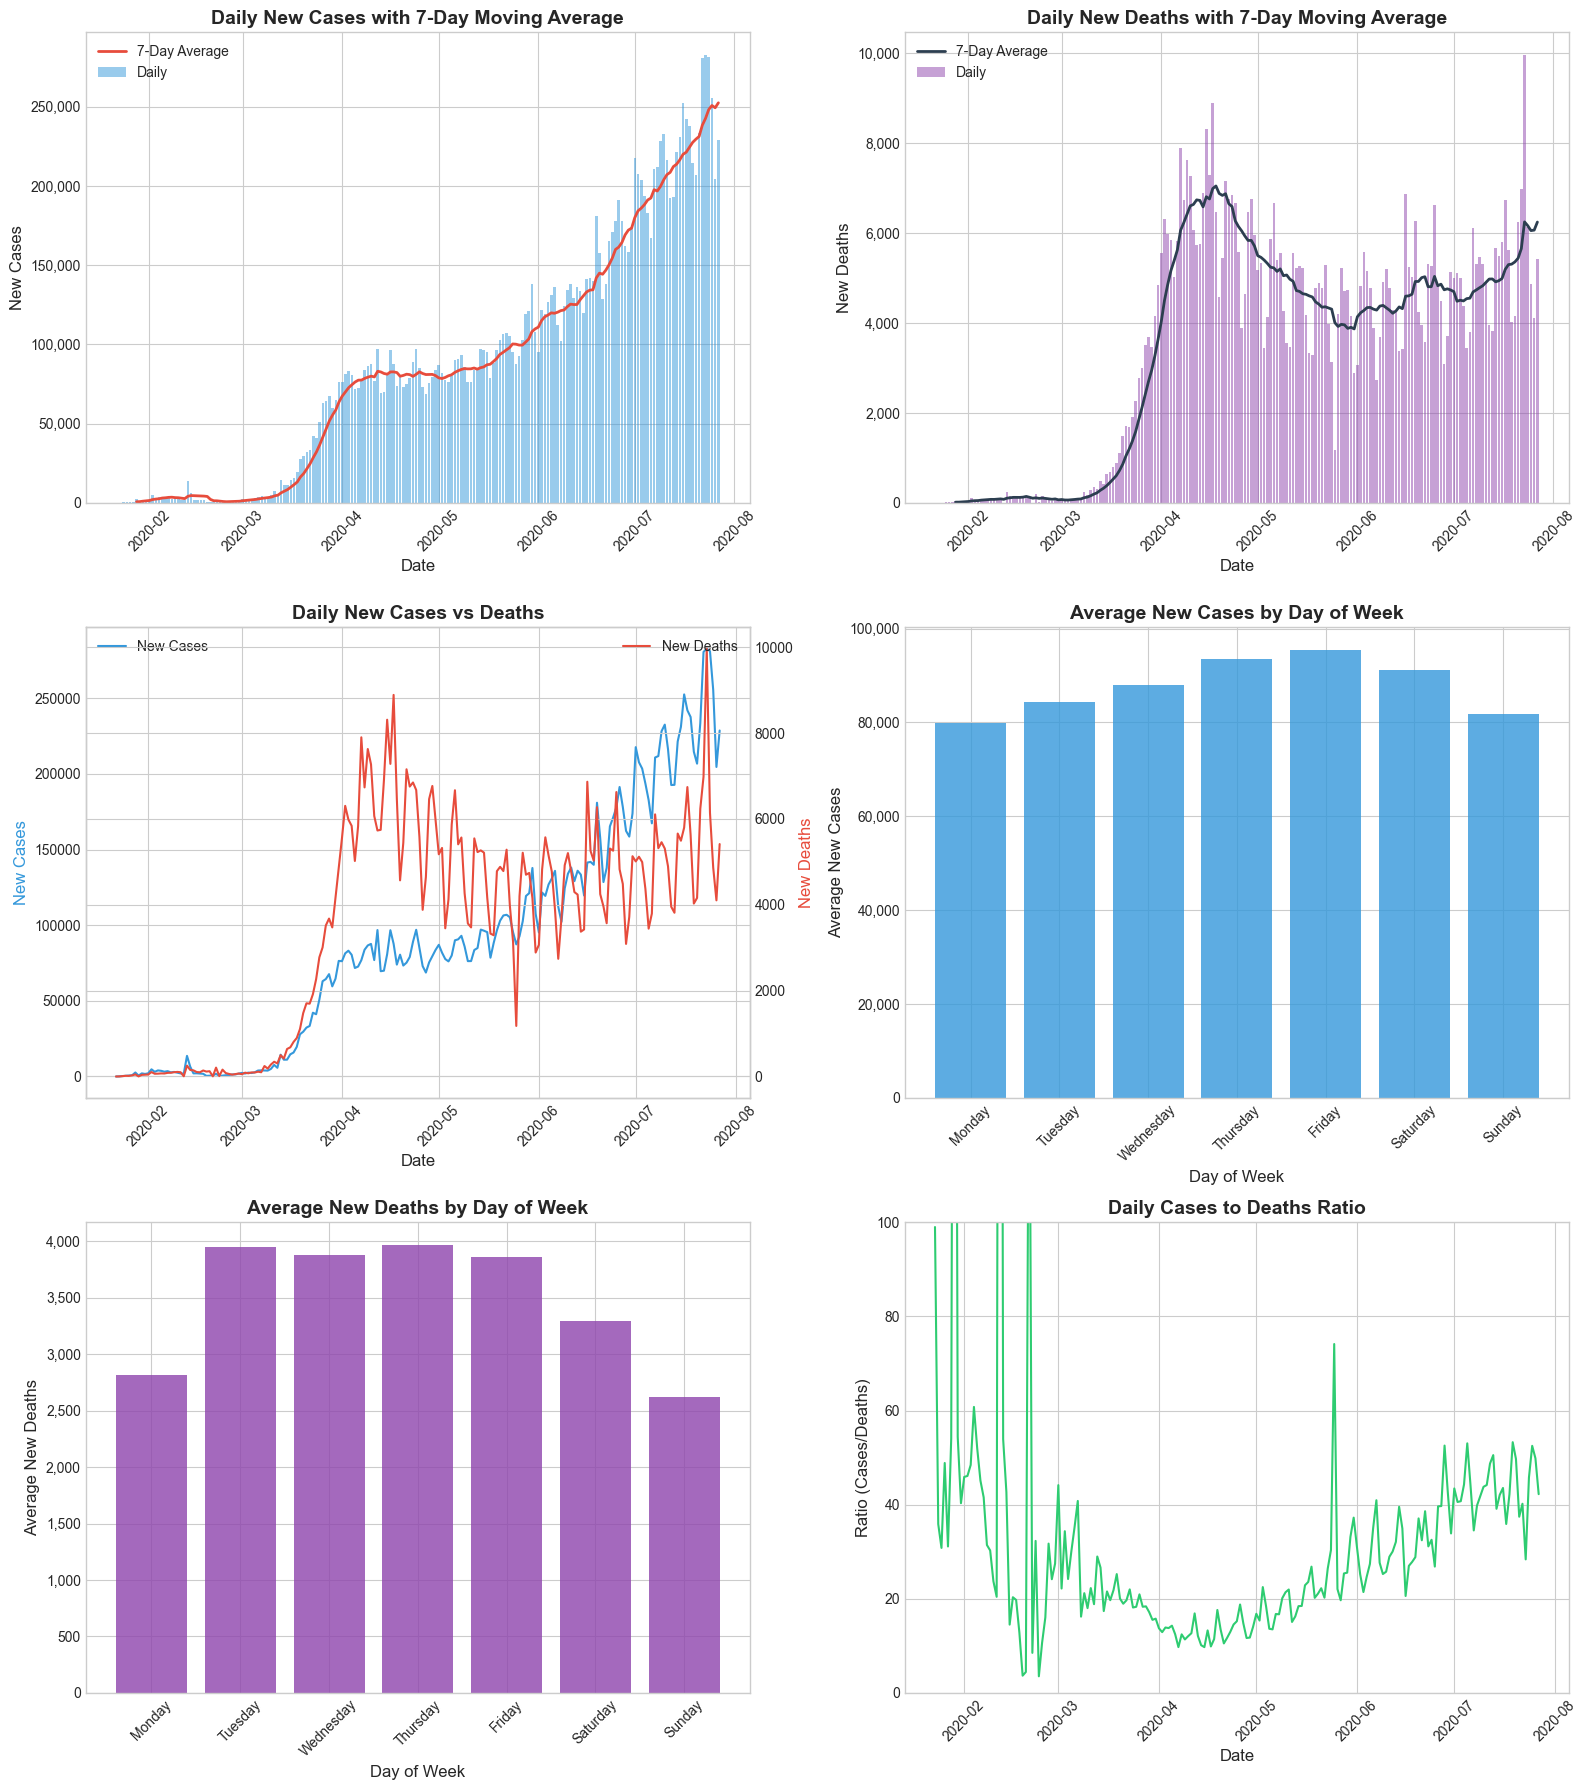


✓ Chart saved: daily_new_cases_deaths_analysis.png


In [8]:
# Daily New Cases and Deaths Analysis
print("=" * 60)
print("DAILY NEW CASES AND DEATHS ANALYSIS")
print("=" * 60)

# Key statistics for new cases
print("\n--- New Cases Statistics ---")
print(f"Average daily new cases: {global_daily['New cases'].mean():,.0f}")
print(f"Maximum daily new cases: {global_daily['New cases'].max():,.0f}")
print(f"Minimum daily new cases: {global_daily['New cases'].min():,.0f}")
print(f"Date of maximum new cases: {global_daily.loc[global_daily['New cases'].idxmax(), 'Date'].strftime('%Y-%m-%d')}")

# Key statistics for new deaths
print("\n--- New Deaths Statistics ---")
print(f"Average daily new deaths: {global_daily['New deaths'].mean():,.0f}")
print(f"Maximum daily new deaths: {global_daily['New deaths'].max():,.0f}")
print(f"Minimum daily new deaths: {global_daily['New deaths'].min():,.0f}")
print(f"Date of maximum new deaths: {global_daily.loc[global_daily['New deaths'].idxmax(), 'Date'].strftime('%Y-%m-%d')}")

# Calculate weekly patterns
global_daily['DayOfWeek'] = global_daily['Date'].dt.dayofweek
weekly_pattern_cases = global_daily.groupby('DayOfWeek')['New cases'].mean()
weekly_pattern_deaths = global_daily.groupby('DayOfWeek')['New deaths'].mean()

print("\n--- Weekly Pattern (Average by Day of Week) ---")
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
for i, day in enumerate(days):
    print(f"{day}: Cases = {weekly_pattern_cases[i]:,.0f}, Deaths = {weekly_pattern_deaths[i]:,.0f}")

# Visualization
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Plot 1: Daily New Cases with Moving Average
ax1 = axes[0, 0]
ax1.bar(global_daily['Date'], global_daily['New cases'], color='#3498db', alpha=0.5, label='Daily')
ax1.plot(global_daily['Date'], global_daily['Weekly_Avg'], color='#e74c3c', linewidth=2, label='7-Day Average')
ax1.set_title('Daily New Cases with 7-Day Moving Average', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('New Cases', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.legend()
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Plot 2: Daily New Deaths with Moving Average
ax2 = axes[0, 1]
ax2.bar(global_daily['Date'], global_daily['New deaths'], color='#8e44ad', alpha=0.5, label='Daily')
ax2.plot(global_daily['Date'], global_daily['Weekly_Deaths_Avg'], color='#2c3e50', linewidth=2, label='7-Day Average')
ax2.set_title('Daily New Deaths with 7-Day Moving Average', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('New Deaths', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.legend()
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Plot 3: Combined New Cases and Deaths
ax3 = axes[1, 0]
ax3_twin = ax3.twinx()
ax3.plot(global_daily['Date'], global_daily['New cases'], color='#3498db', label='New Cases', linewidth=1.5)
ax3_twin.plot(global_daily['Date'], global_daily['New deaths'], color='#e74c3c', label='New Deaths', linewidth=1.5)
ax3.set_title('Daily New Cases vs Deaths', fontsize=14, fontweight='bold')
ax3.set_xlabel('Date', fontsize=12)
ax3.set_ylabel('New Cases', color='#3498db', fontsize=12)
ax3_twin.set_ylabel('New Deaths', color='#e74c3c', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
ax3.legend(loc='upper left')
ax3_twin.legend(loc='upper right')

# Plot 4: Weekly Pattern - Cases
ax4 = axes[1, 1]
bars = ax4.bar(days, weekly_pattern_cases, color='#3498db', alpha=0.8)
ax4.set_title('Average New Cases by Day of Week', fontsize=14, fontweight='bold')
ax4.set_xlabel('Day of Week', fontsize=12)
ax4.set_ylabel('Average New Cases', fontsize=12)
ax4.tick_params(axis='x', rotation=45)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Plot 5: Weekly Pattern - Deaths
ax5 = axes[2, 0]
bars = ax5.bar(days, weekly_pattern_deaths, color='#8e44ad', alpha=0.8)
ax5.set_title('Average New Deaths by Day of Week', fontsize=14, fontweight='bold')
ax5.set_xlabel('Day of Week', fontsize=12)
ax5.set_ylabel('Average New Deaths', fontsize=12)
ax5.tick_params(axis='x', rotation=45)
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Plot 6: Cases to Deaths Ratio Over Time
global_daily['Cases_to_Deaths_Ratio'] = global_daily['New cases'] / global_daily['New deaths'].replace(0, np.nan)
ax6 = axes[2, 1]
ax6.plot(global_daily['Date'], global_daily['Cases_to_Deaths_Ratio'], color='#2ecc71', linewidth=1.5)
ax6.set_title('Daily Cases to Deaths Ratio', fontsize=14, fontweight='bold')
ax6.set_xlabel('Date', fontsize=12)
ax6.set_ylabel('Ratio (Cases/Deaths)', fontsize=12)
ax6.tick_params(axis='x', rotation=45)
ax6.set_ylim(0, 100)  # Cap for better visualization

plt.tight_layout()
plt.savefig('/Users/ankitkumar/Desktop/final_data/daily_new_cases_deaths_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Chart saved: daily_new_cases_deaths_analysis.png")

## 8. Mortality Rate Analysis

This section calculates and visualizes the global mortality rate (Deaths/Confirmed) over time. The mortality rate is a crucial indicator for understanding the lethality of the virus and the effectiveness of medical interventions.

### Analysis Highlights:
- **Initial High Rate (January-February 2020):** Higher mortality rate due to limited testing and severe cases being prioritized
- **Declining Trend (March-April 2020):** As testing expanded, more mild cases were detected, lowering the overall rate
- **Stabilization (May-June 2020):** Mortality rate stabilized as healthcare systems adapted
- **Case Fatality Rate vs Infection Fatality Rate:** The analysis shows the case fatality rate based on confirmed cases

The analysis reveals that the mortality rate has shown a general declining trend over time. This can be attributed to several factors: expanded testing capturing more mild cases, improved treatment protocols, better healthcare preparation, and earlier detection of cases. The declining mortality rate is a positive indicator of improving pandemic management.

MORTALITY RATE ANALYSIS

--- Mortality Rate Statistics ---
Initial Mortality Rate (first 1000+ cases): 2.93%
Maximum Mortality Rate: 7.18%
Date of Maximum Mortality Rate: 2020-04-29
Latest Mortality Rate: 3.97%
Average Mortality Rate: 4.86%

--- Monthly Mortality Rate ---
2020-01: 2.15%
2020-02: 3.44%
2020-03: 5.10%
2020-04: 7.18%
2020-05: 6.04%
2020-06: 4.89%
2020-07: 3.97%


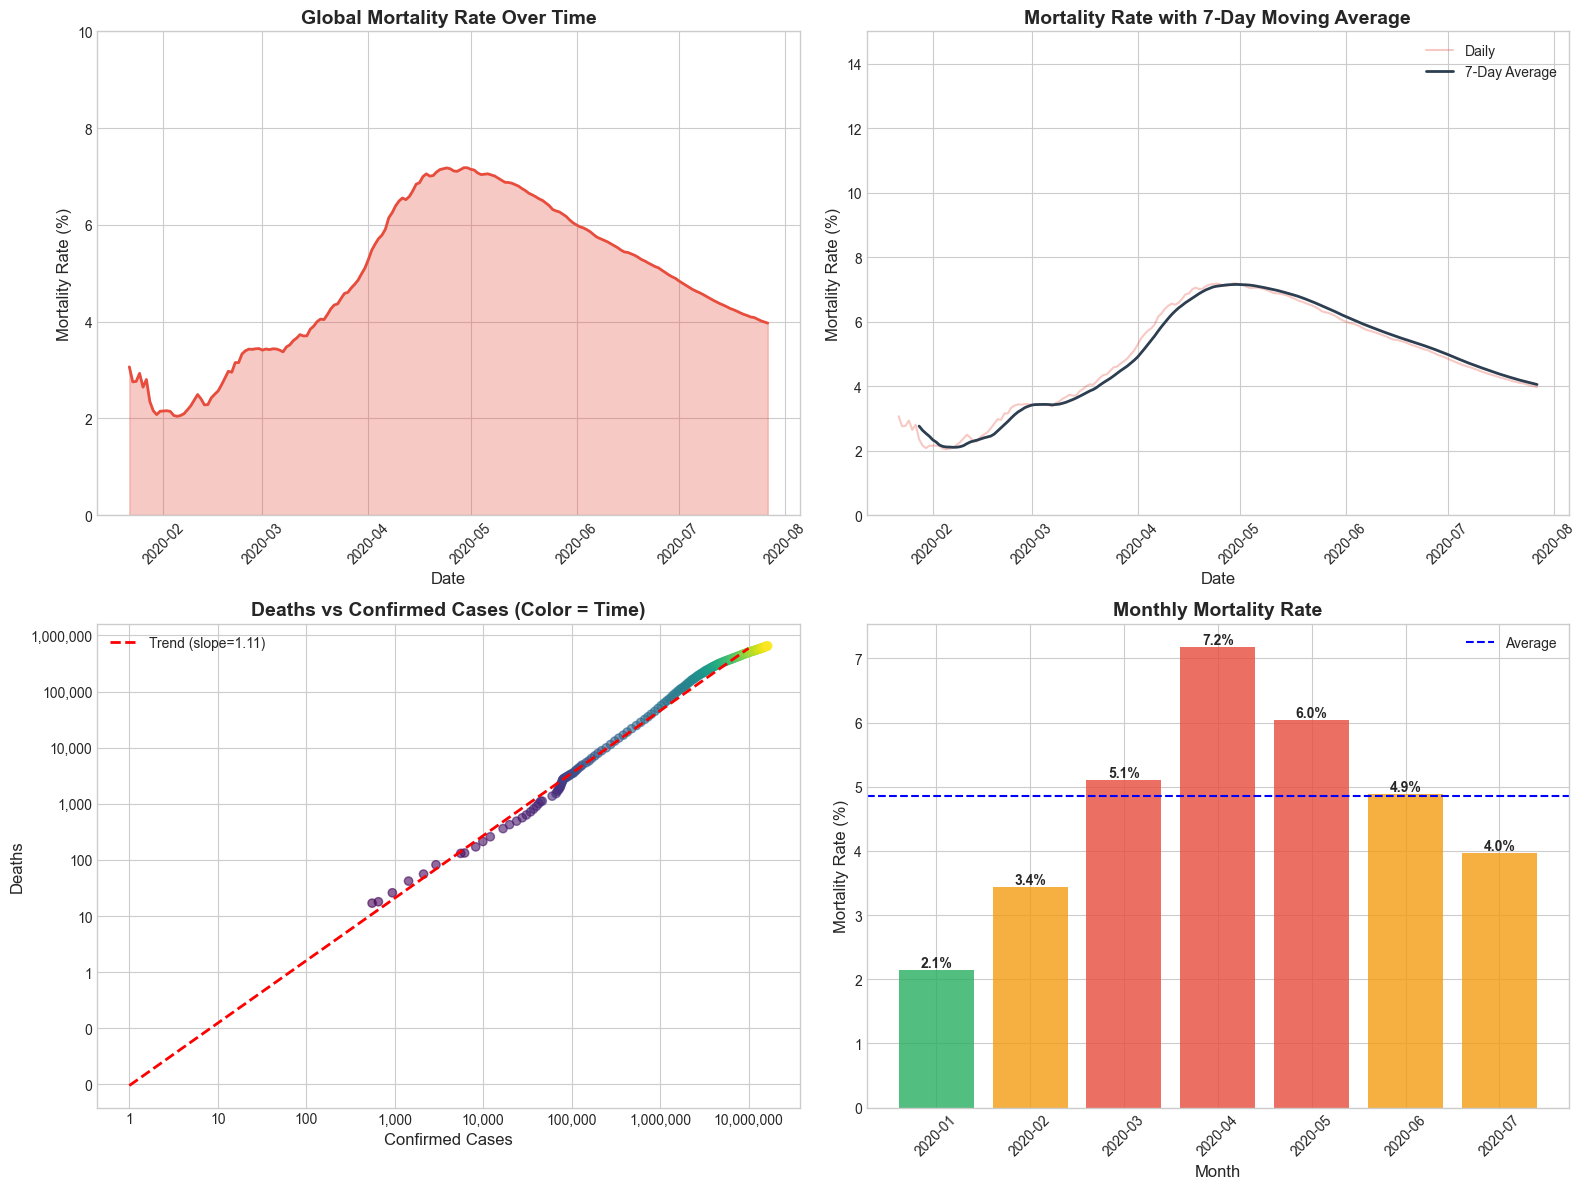


✓ Chart saved: mortality_rate_analysis.png


In [9]:
# Mortality Rate Analysis
print("=" * 60)
print("MORTALITY RATE ANALYSIS")
print("=" * 60)

# Calculate mortality rate (Case Fatality Rate - CFR)
global_daily['Mortality_Rate'] = (global_daily['Deaths'] / global_daily['Confirmed']) * 100

# Key statistics
print("\n--- Mortality Rate Statistics ---")
print(f"Initial Mortality Rate (first 1000+ cases): {global_daily[global_daily['Confirmed'] >= 1000]['Mortality_Rate'].iloc[0]:.2f}%")
print(f"Maximum Mortality Rate: {global_daily['Mortality_Rate'].max():.2f}%")
print(f"Date of Maximum Mortality Rate: {global_daily.loc[global_daily['Mortality_Rate'].idxmax(), 'Date'].strftime('%Y-%m-%d')}")
print(f"Latest Mortality Rate: {global_daily['Mortality_Rate'].iloc[-1]:.2f}%")
print(f"Average Mortality Rate: {global_daily['Mortality_Rate'].mean():.2f}%")

# Monthly mortality rate
print("\n--- Monthly Mortality Rate ---")
monthly_mortality = global_daily.groupby('Month').apply(lambda x: (x['Deaths'].iloc[-1] / x['Confirmed'].iloc[-1]) * 100)
for month, rate in monthly_mortality.items():
    print(f"{month}: {rate:.2f}%")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Mortality Rate Over Time
ax1 = axes[0, 0]
ax1.plot(global_daily['Date'], global_daily['Mortality_Rate'], color='#e74c3c', linewidth=2)
ax1.fill_between(global_daily['Date'], global_daily['Mortality_Rate'], alpha=0.3, color='#e74c3c')
ax1.set_title('Global Mortality Rate Over Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Mortality Rate (%)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylim(0, max(global_daily['Mortality_Rate'].max() * 1.1, 10))

# Plot 2: Mortality Rate with 7-Day Average
global_daily['Mortality_Rate_Avg'] = global_daily['Mortality_Rate'].rolling(window=7).mean()
ax2 = axes[0, 1]
ax2.plot(global_daily['Date'], global_daily['Mortality_Rate'], alpha=0.3, color='#e74c3c', label='Daily')
ax2.plot(global_daily['Date'], global_daily['Mortality_Rate_Avg'], color='#2c3e50', linewidth=2, label='7-Day Average')
ax2.set_title('Mortality Rate with 7-Day Moving Average', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Mortality Rate (%)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.legend()
ax2.set_ylim(0, 15)

# Plot 3: Deaths vs Confirmed (Log Scale)
ax3 = axes[1, 0]
ax3.scatter(global_daily['Confirmed'], global_daily['Deaths'], c=global_daily.index, cmap='viridis', alpha=0.6)
ax3.set_title('Deaths vs Confirmed Cases (Color = Time)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Confirmed Cases', fontsize=12)
ax3.set_ylabel('Deaths', fontsize=12)
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Add trend line
z = np.polyfit(np.log10(global_daily['Confirmed'][global_daily['Confirmed'] > 0]), 
               np.log10(global_daily['Deaths'][global_daily['Deaths'] > 0]), 1)
p = np.poly1d(z)
x_line = np.logspace(0, 7, 100)
ax3.plot(x_line, 10**p(np.log10(x_line)), 'r--', linewidth=2, label=f'Trend (slope={z[0]:.2f})')
ax3.legend()

# Plot 4: Monthly Mortality Rate Comparison
ax4 = axes[1, 1]
months = monthly_mortality.index.astype(str)
rates = monthly_mortality.values
colors = ['#e74c3c' if r > 5 else '#f39c12' if r > 3 else '#27ae60' for r in rates]
bars = ax4.bar(months, rates, color=colors, alpha=0.8)
ax4.set_title('Monthly Mortality Rate', fontsize=14, fontweight='bold')
ax4.set_xlabel('Month', fontsize=12)
ax4.set_ylabel('Mortality Rate (%)', fontsize=12)
ax4.tick_params(axis='x', rotation=45)
ax4.axhline(y=global_daily['Mortality_Rate'].mean(), color='blue', linestyle='--', label='Average')
ax4.legend()

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax4.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/ankitkumar/Desktop/final_data/mortality_rate_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Chart saved: mortality_rate_analysis.png")

## 9. Recovery Rate Analysis

This section calculates and visualizes the global recovery rate (Recovered/Confirmed) over time. The recovery rate indicates the proportion of patients who have successfully recovered from COVID-19, reflecting the effectiveness of treatment and the natural progression of the disease.

### Analysis Highlights:
- **Initial Low Rate (January-February 2020):** Few recoveries initially as the pandemic was just beginning
- **Gradual Increase (March-April 2020):** As more patients completed their recovery cycle, rates increased
- **Significant Improvement (May-June 2020):** Recovery rates improved substantially as treatment protocols evolved
- **Active vs Recovered:** Shows the changing composition of confirmed cases over time

The analysis demonstrates a clear upward trend in recovery rates over time. This is a positive indicator that reflects improved medical understanding, better treatment protocols, and healthcare systems becoming more adept at managing COVID-19 cases. The rising recovery rate is one of the most encouraging trends in the pandemic data.

RECOVERY RATE ANALYSIS

--- Recovery Rate Statistics ---
Maximum Recovery Rate: 57.45%
Date of Maximum Recovery Rate: 2020-07-27
Latest Recovery Rate: 57.45%
Average Recovery Rate: 34.34%

--- Monthly Recovery Rate ---
2020-01: 2.21%
2020-02: 44.91%
2020-03: 19.98%
2020-04: 30.27%
2020-05: 41.80%
2020-06: 50.54%
2020-07: 57.45%


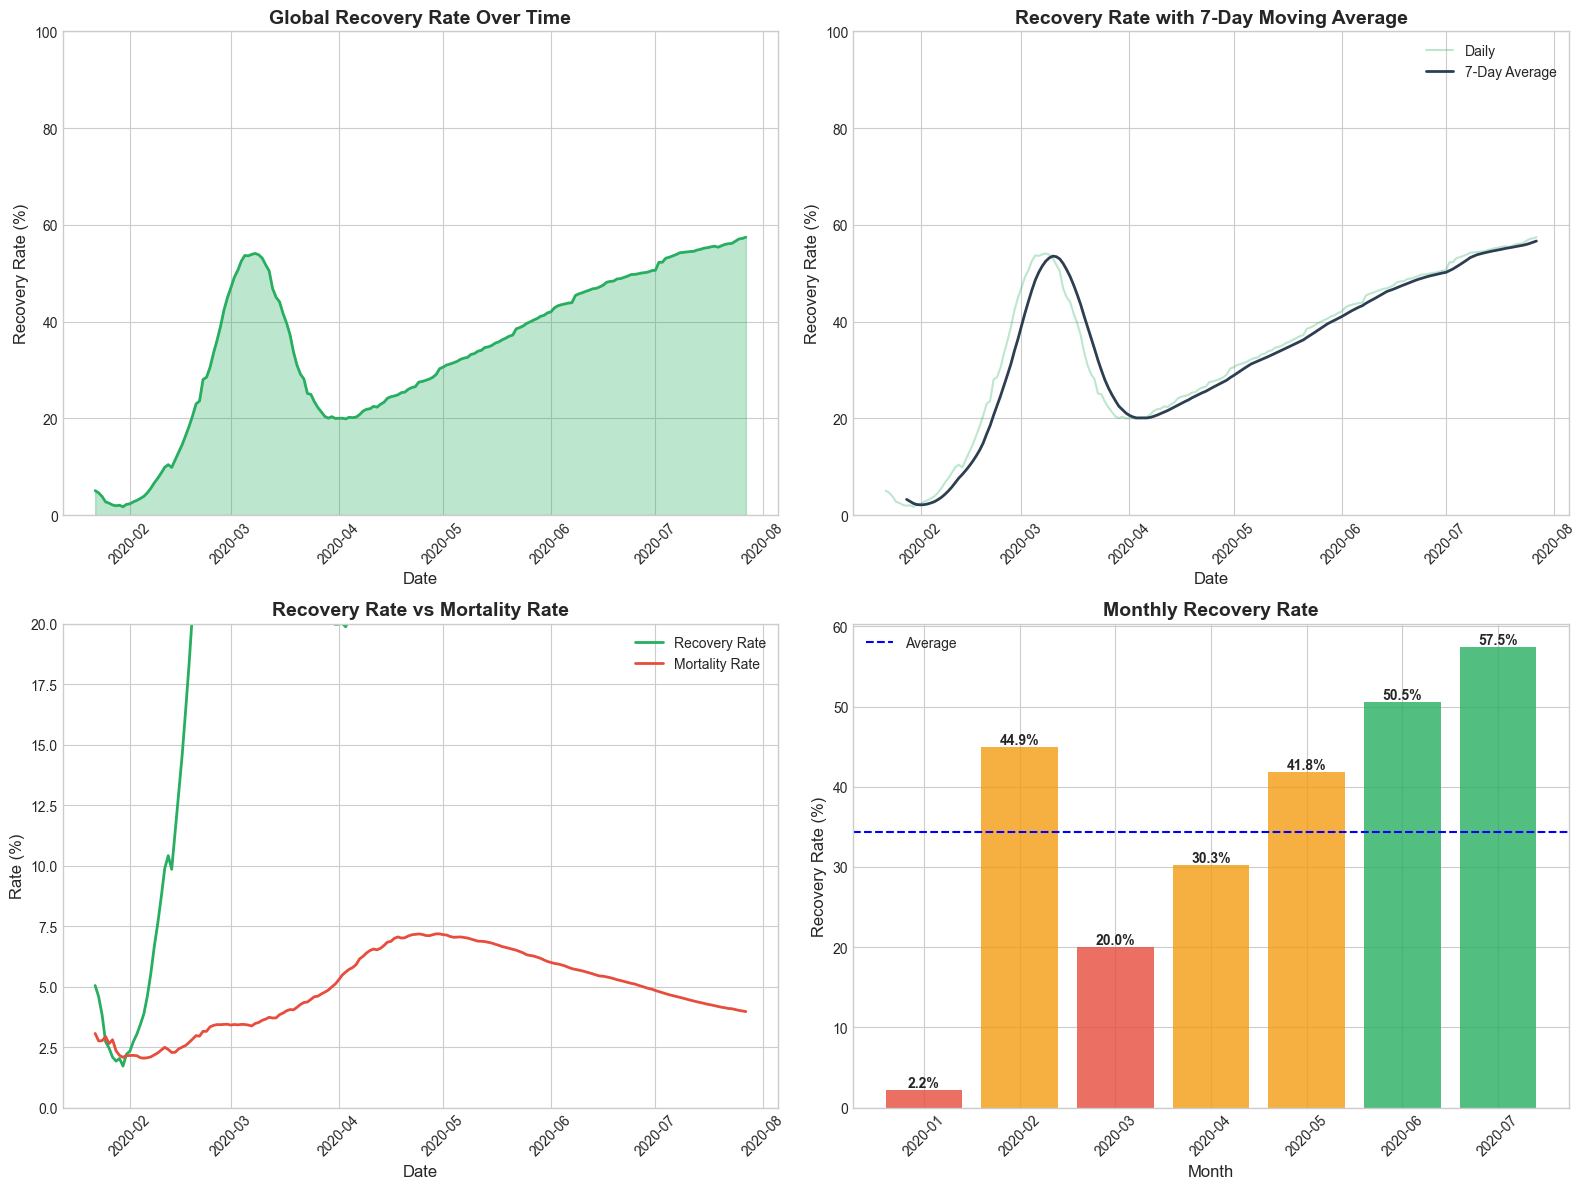


✓ Chart saved: recovery_rate_analysis.png


In [10]:
# Recovery Rate Analysis
print("=" * 60)
print("RECOVERY RATE ANALYSIS")
print("=" * 60)

# Calculate recovery rate
global_daily['Recovery_Rate'] = (global_daily['Recovered'] / global_daily['Confirmed']) * 100

# Key statistics
print("\n--- Recovery Rate Statistics ---")
print(f"Maximum Recovery Rate: {global_daily['Recovery_Rate'].max():.2f}%")
print(f"Date of Maximum Recovery Rate: {global_daily.loc[global_daily['Recovery_Rate'].idxmax(), 'Date'].strftime('%Y-%m-%d')}")
print(f"Latest Recovery Rate: {global_daily['Recovery_Rate'].iloc[-1]:.2f}%")
print(f"Average Recovery Rate: {global_daily['Recovery_Rate'].mean():.2f}%")

# Monthly recovery rate
print("\n--- Monthly Recovery Rate ---")
monthly_recovery = global_daily.groupby('Month').apply(lambda x: (x['Recovered'].iloc[-1] / x['Confirmed'].iloc[-1]) * 100)
for month, rate in monthly_recovery.items():
    print(f"{month}: {rate:.2f}%")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Recovery Rate Over Time
ax1 = axes[0, 0]
ax1.plot(global_daily['Date'], global_daily['Recovery_Rate'], color='#27ae60', linewidth=2)
ax1.fill_between(global_daily['Date'], global_daily['Recovery_Rate'], alpha=0.3, color='#27ae60')
ax1.set_title('Global Recovery Rate Over Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Recovery Rate (%)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylim(0, 100)

# Plot 2: Recovery Rate with 7-Day Average
global_daily['Recovery_Rate_Avg'] = global_daily['Recovery_Rate'].rolling(window=7).mean()
ax2 = axes[0, 1]
ax2.plot(global_daily['Date'], global_daily['Recovery_Rate'], alpha=0.3, color='#27ae60', label='Daily')
ax2.plot(global_daily['Date'], global_daily['Recovery_Rate_Avg'], color='#2c3e50', linewidth=2, label='7-Day Average')
ax2.set_title('Recovery Rate with 7-Day Moving Average', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Recovery Rate (%)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.legend()
ax2.set_ylim(0, 100)

# Plot 3: Recovery vs Deaths Comparison
ax3 = axes[1, 0]
ax3.plot(global_daily['Date'], global_daily['Recovery_Rate'], label='Recovery Rate', color='#27ae60', linewidth=2)
ax3.plot(global_daily['Date'], global_daily['Mortality_Rate'], label='Mortality Rate', color='#e74c3c', linewidth=2)
ax3.set_title('Recovery Rate vs Mortality Rate', fontsize=14, fontweight='bold')
ax3.set_xlabel('Date', fontsize=12)
ax3.set_ylabel('Rate (%)', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
ax3.legend()
ax3.set_ylim(0, 20)

# Plot 4: Monthly Recovery Rate Comparison
ax4 = axes[1, 1]
months = monthly_recovery.index.astype(str)
rates = monthly_recovery.values
colors = ['#27ae60' if r > 50 else '#f39c12' if r > 30 else '#e74c3c' for r in rates]
bars = ax4.bar(months, rates, color=colors, alpha=0.8)
ax4.set_title('Monthly Recovery Rate', fontsize=14, fontweight='bold')
ax4.set_xlabel('Month', fontsize=12)
ax4.set_ylabel('Recovery Rate (%)', fontsize=12)
ax4.tick_params(axis='x', rotation=45)
ax4.axhline(y=global_daily['Recovery_Rate'].mean(), color='blue', linestyle='--', label='Average')
ax4.legend()

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax4.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/ankitkumar/Desktop/final_data/recovery_rate_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Chart saved: recovery_rate_analysis.png")

## 10. Growth Rate Analysis

This section calculates daily and weekly growth rates for confirmed cases to understand the speed of pandemic spread and the impact of interventions. Growth rate analysis is crucial for evaluating the effectiveness of containment measures like lockdowns.

### Analysis Highlights:
- **Exponential Growth Phase (February-March 2020):** High growth rates as the virus spread globally
- **Lockdown Impact (April 2020):** Significant reduction in growth rates following global lockdowns
- **Stabilization (May-June 2020):** Growth rates stabilized at lower levels
- **Doubling Time:** Calculated to show how quickly cases were doubling at different phases

The analysis reveals a clear pattern: the global growth rate declined significantly after lockdowns were implemented in March-April 2020. The doubling time of cases increased from days to weeks, indicating that containment measures were effective in slowing the spread. This is strong evidence supporting the effectiveness of lockdown measures in controlling the pandemic.

GROWTH RATE ANALYSIS

--- Growth Rate Statistics ---
Average Daily Growth Rate: 6.05%
Maximum Daily Growth Rate: 90.57%
Date of Maximum Growth Rate: 2020-01-28
Latest Weekly Growth Rate: 1.63%

--- Growth Rate by Phase ---
Early Phase (Jan-Feb 2020): 15.51% avg daily growth
Pre-Lockdown (Mar 1-15): 4.48% avg daily growth
Post-Lockdown (Mar 16 - Apr): 6.72% avg daily growth
Stabilization (May-Jul): 1.86% avg daily growth


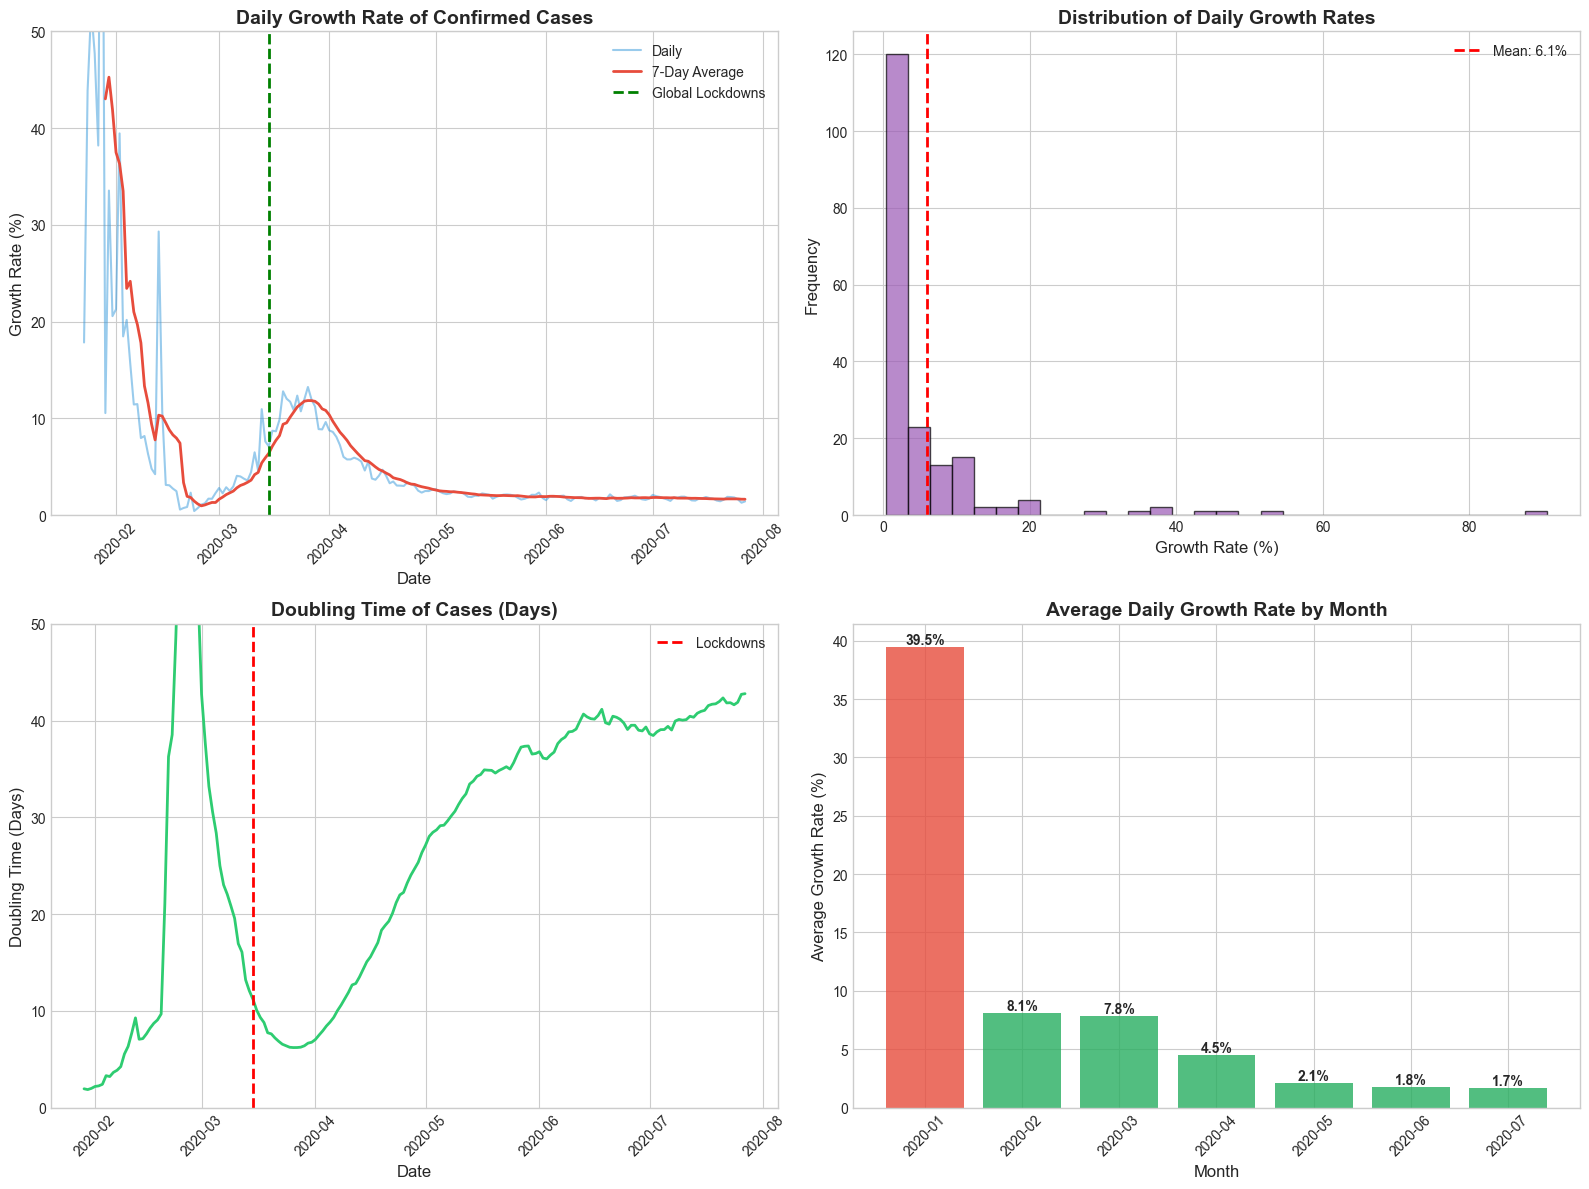


✓ Chart saved: growth_rate_analysis.png


In [11]:
# Growth Rate Analysis
print("=" * 60)
print("GROWTH RATE ANALYSIS")
print("=" * 60)

# Calculate daily growth rate
global_daily['Daily_Growth_Rate'] = global_daily['Confirmed'].pct_change() * 100

# Calculate 7-day average growth rate
global_daily['Weekly_Growth_Rate'] = global_daily['Daily_Growth_Rate'].rolling(window=7).mean()

# Calculate doubling time (using 7-day growth rate)
global_daily['Doubling_Time'] = np.log(2) / np.log(1 + global_daily['Weekly_Growth_Rate']/100)

# Key statistics
print("\n--- Growth Rate Statistics ---")
print(f"Average Daily Growth Rate: {global_daily['Daily_Growth_Rate'].mean():.2f}%")
print(f"Maximum Daily Growth Rate: {global_daily['Daily_Growth_Rate'].max():.2f}%")
print(f"Date of Maximum Growth Rate: {global_daily.loc[global_daily['Daily_Growth_Rate'].idxmax(), 'Date'].strftime('%Y-%m-%d')}")
print(f"Latest Weekly Growth Rate: {global_daily['Weekly_Growth_Rate'].iloc[-1]:.2f}%")

# Phase analysis
print("\n--- Growth Rate by Phase ---")
# Early phase (Jan-Feb 2020)
early_phase = global_daily[global_daily['Date'] < '2020-03-01']
print(f"Early Phase (Jan-Feb 2020): {early_phase['Daily_Growth_Rate'].mean():.2f}% avg daily growth")

# Pre-lockdown (March 1-15)
pre_lockdown = global_daily[(global_daily['Date'] >= '2020-03-01') & (global_daily['Date'] < '2020-03-15')]
print(f"Pre-Lockdown (Mar 1-15): {pre_lockdown['Daily_Growth_Rate'].mean():.2f}% avg daily growth")

# Post-lockdown (March 16 - April)
post_lockdown = global_daily[(global_daily['Date'] >= '2020-03-16') & (global_daily['Date'] < '2020-05-01')]
print(f"Post-Lockdown (Mar 16 - Apr): {post_lockdown['Daily_Growth_Rate'].mean():.2f}% avg daily growth")

# Stabilization (May-July)
stabilization = global_daily[global_daily['Date'] >= '2020-05-01']
print(f"Stabilization (May-Jul): {stabilization['Daily_Growth_Rate'].mean():.2f}% avg daily growth")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Daily Growth Rate
ax1 = axes[0, 0]
ax1.plot(global_daily['Date'], global_daily['Daily_Growth_Rate'], color='#3498db', alpha=0.5, label='Daily')
ax1.plot(global_daily['Date'], global_daily['Weekly_Growth_Rate'], color='#e74c3c', linewidth=2, label='7-Day Average')
ax1.set_title('Daily Growth Rate of Confirmed Cases', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Growth Rate (%)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.legend()
ax1.set_ylim(0, 50)

# Add lockdown reference line
ax1.axvline(x=pd.Timestamp('2020-03-15'), color='green', linestyle='--', linewidth=2, label='Global Lockdowns')
ax1.legend()

# Plot 2: Growth Rate Distribution
ax2 = axes[0, 1]
ax2.hist(global_daily['Daily_Growth_Rate'].dropna(), bins=30, color='#9b59b6', alpha=0.7, edgecolor='black')
ax2.axvline(x=global_daily['Daily_Growth_Rate'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {global_daily["Daily_Growth_Rate"].mean():.1f}%')
ax2.set_title('Distribution of Daily Growth Rates', fontsize=14, fontweight='bold')
ax2.set_xlabel('Growth Rate (%)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.legend()

# Plot 3: Doubling Time
ax3 = axes[1, 0]
# Filter reasonable doubling times
doubling_filtered = global_daily['Doubling_Time'].copy()
doubling_filtered = doubling_filtered.replace([np.inf, -np.inf], np.nan)
doubling_filtered = doubling_filtered.clip(0, 100)  # Cap at 100 days
ax3.plot(global_daily['Date'], doubling_filtered, color='#2ecc71', linewidth=2)
ax3.set_title('Doubling Time of Cases (Days)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Date', fontsize=12)
ax3.set_ylabel('Doubling Time (Days)', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
ax3.set_ylim(0, 50)
ax3.axvline(x=pd.Timestamp('2020-03-15'), color='red', linestyle='--', linewidth=2, label='Lockdowns')
ax3.legend()

# Plot 4: Growth Rate by Month
ax4 = axes[1, 1]
monthly_growth = global_daily.groupby('Month')['Daily_Growth_Rate'].mean()
months = monthly_growth.index.astype(str)
rates = monthly_growth.values
colors = ['#e74c3c' if r > 20 else '#f39c12' if r > 10 else '#27ae60' for r in rates]
bars = ax4.bar(months, rates, color=colors, alpha=0.8)
ax4.set_title('Average Daily Growth Rate by Month', fontsize=14, fontweight='bold')
ax4.set_xlabel('Month', fontsize=12)
ax4.set_ylabel('Average Growth Rate (%)', fontsize=12)
ax4.tick_params(axis='x', rotation=45)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax4.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/ankitkumar/Desktop/final_data/growth_rate_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Chart saved: growth_rate_analysis.png")

## 11. WHO Region Comparison

This section compares COVID-19 trends across different WHO regions (Americas, Europe, Western Pacific, South-East Asia, Africa, Eastern Mediterranean) to understand regional variations in the pandemic's impact.

### Analysis Highlights:
- **Americas:** Highest case numbers globally, with the US being the most affected
- **Europe:** Significant early outbreak, particularly in Italy, Spain, and UK
- **Western Pacific:** Initial outbreak in China, followed by controlled spread in other countries
- **South-East Asia:** Delayed onset but significant growth in India
- **Africa:** Lower reported cases but limited testing capacity
- **Eastern Mediterranean:** Significant spread in Iran and Saudi Arabia

The regional comparison reveals that different regions experienced the pandemic at different times and with varying severity. The Americas and Europe were the most affected regions during this period, while some regions like Africa reported lower numbers possibly due to younger populations, limited testing, or actual lower transmission. This analysis helps understand the global distribution of the pandemic.

WHO REGION COMPARISON

--- Latest Data by WHO Region ---
           WHO Region  Confirmed  Deaths  Recovered  Mortality_Rate  Recovery_Rate
               Africa     723207   12223     440645        1.690111      60.929305
             Americas    8839286  342732    4468616        3.877372      50.554038
Eastern Mediterranean    1490744   38339    1201400        2.571803      80.590631
               Europe    3299523  211144    1993723        6.399228      60.424583
      South-East Asia    1835297   41349    1156933        2.252987      63.037917
      Western Pacific     292428    8249     206770        2.820865      70.708003


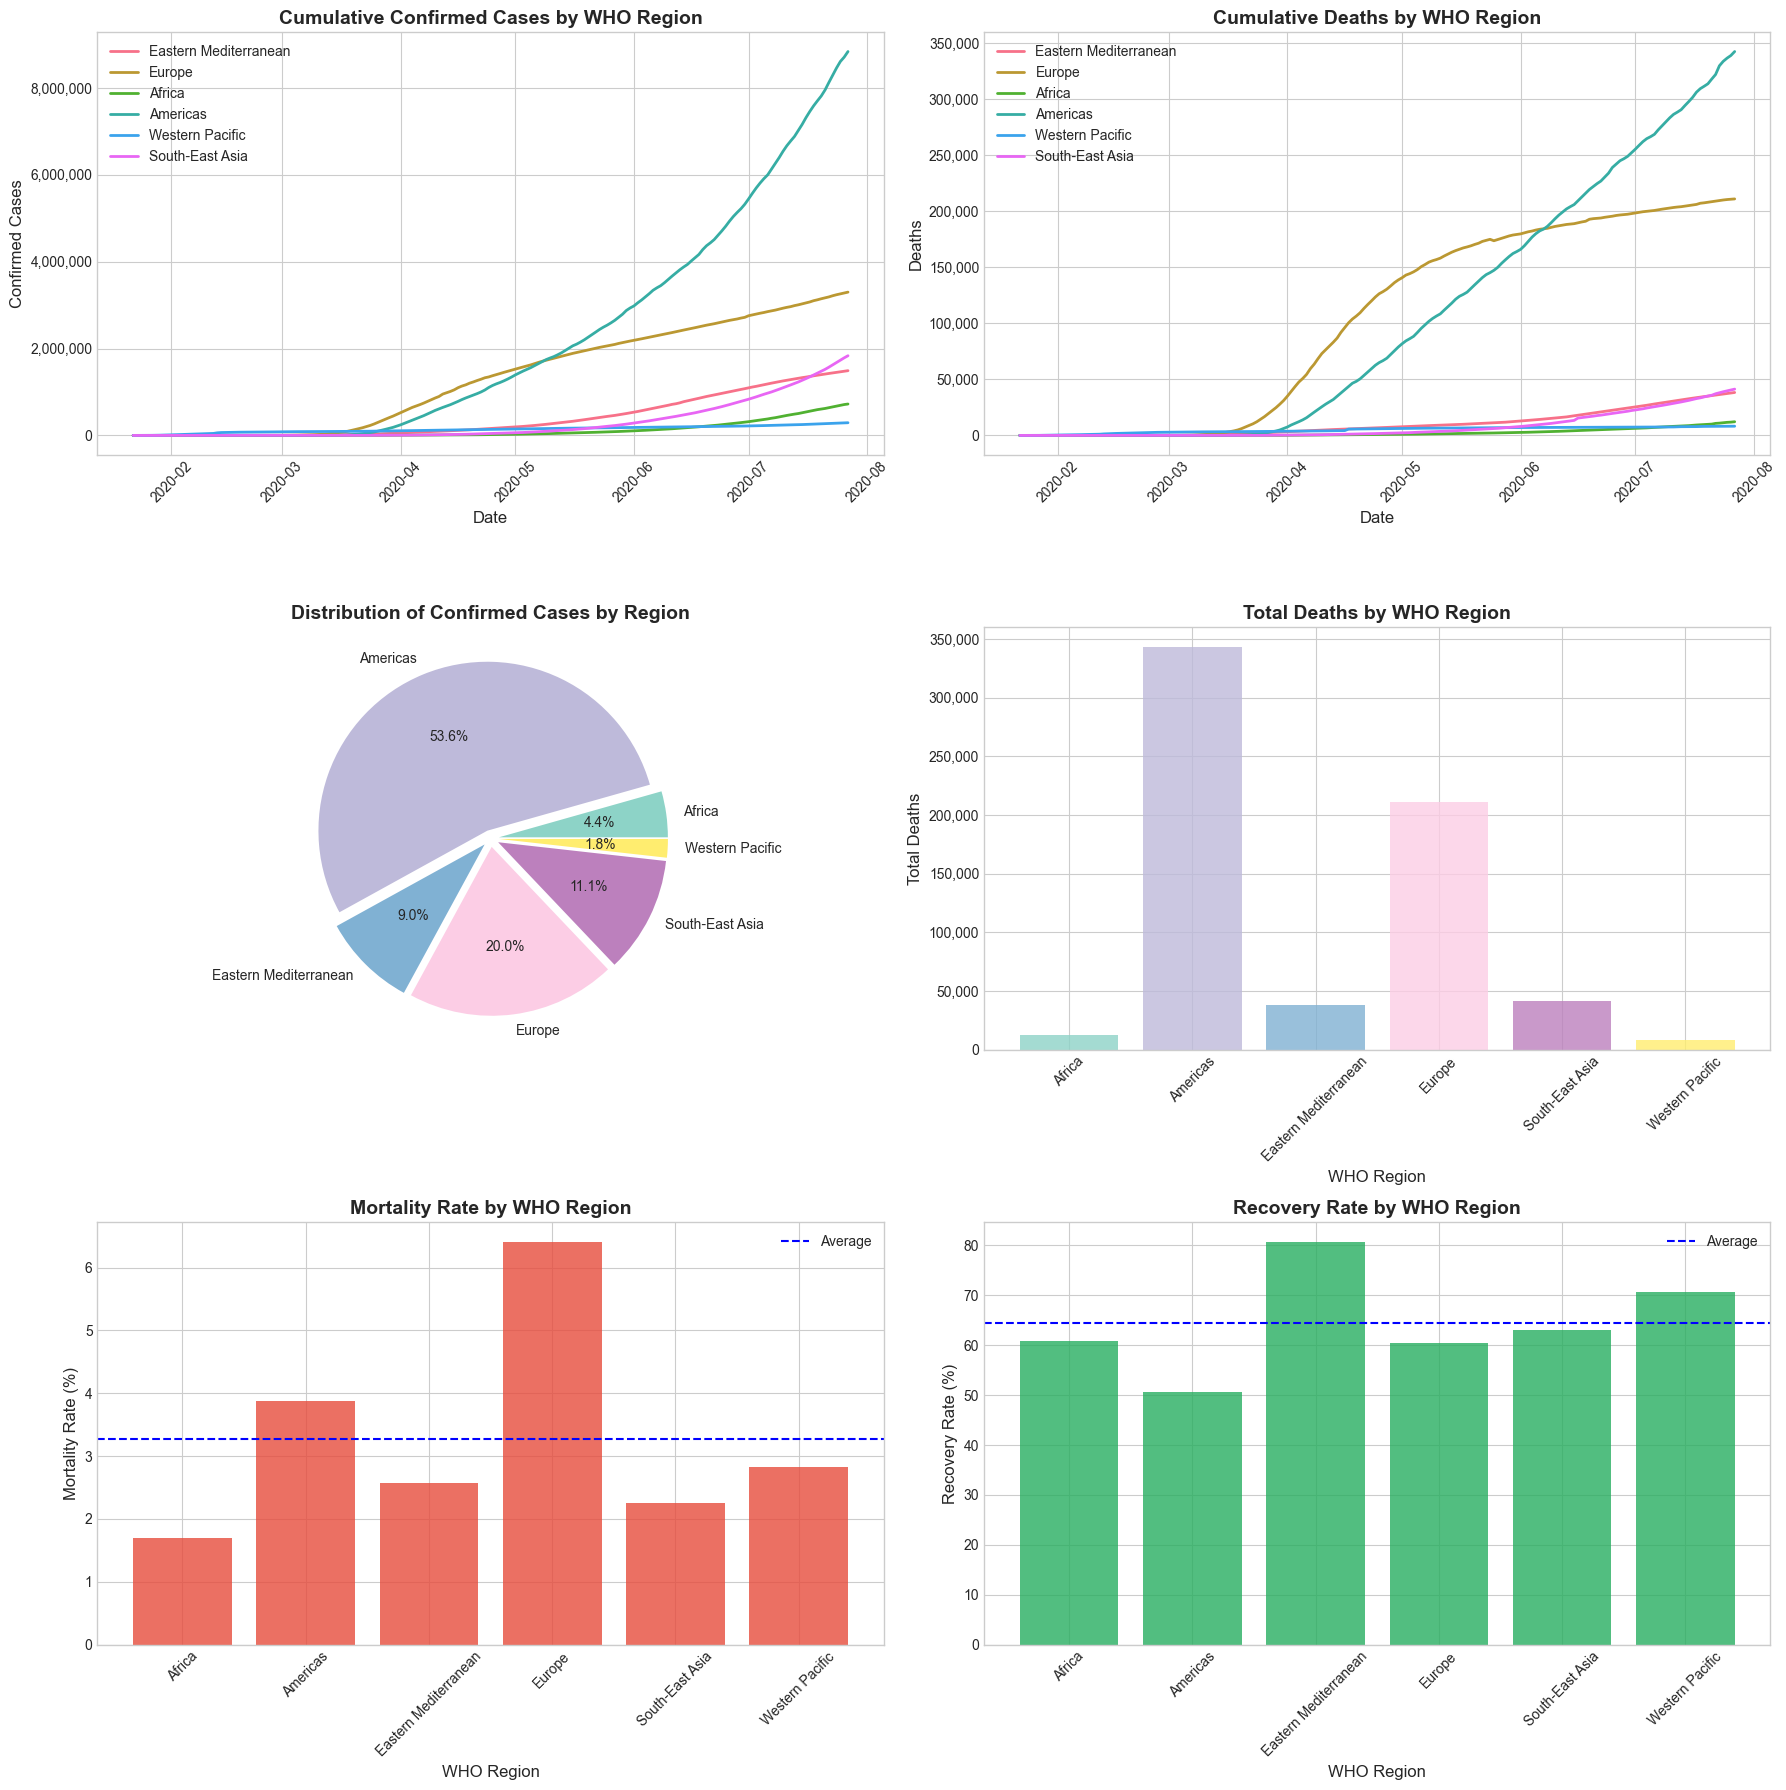


✓ Chart saved: who_region_comparison.png


In [12]:
# WHO Region Comparison
print("=" * 60)
print("WHO REGION COMPARISON")
print("=" * 60)

# Aggregate by WHO Region and Date
region_daily = df.groupby(['Date', 'WHO Region']).agg({
    'Confirmed': 'sum',
    'Deaths': 'sum',
    'Recovered': 'sum',
    'Active': 'sum',
    'New cases': 'sum',
    'New deaths': 'sum',
    'New recovered': 'sum'
}).reset_index()

# Get latest data by region
latest_date = df['Date'].max()
latest_by_region = df[df['Date'] == latest_date].groupby('WHO Region').agg({
    'Confirmed': 'sum',
    'Deaths': 'sum',
    'Recovered': 'sum'
}).reset_index()

# Calculate mortality and recovery rates
latest_by_region['Mortality_Rate'] = (latest_by_region['Deaths'] / latest_by_region['Confirmed']) * 100
latest_by_region['Recovery_Rate'] = (latest_by_region['Recovered'] / latest_by_region['Confirmed']) * 100

print("\n--- Latest Data by WHO Region ---")
print(latest_by_region.to_string(index=False))

# Regional trend over time
region_trend = region_daily.groupby('Date')['Confirmed'].sum().reset_index()
region_trend.columns = ['Date', 'Global']

for region in df['WHO Region'].unique():
    region_data = region_daily[region_daily['WHO Region'] == region][['Date', 'Confirmed']]
    region_data.columns = ['Date', region]
    region_trend = region_trend.merge(region_data, on='Date', how='left')

# Visualization
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# Plot 1: Confirmed Cases by Region
ax1 = axes[0, 0]
for region in df['WHO Region'].unique():
    region_data = region_daily[region_daily['WHO Region'] == region]
    ax1.plot(region_data['Date'], region_data['Confirmed'], label=region, linewidth=2)
ax1.set_title('Cumulative Confirmed Cases by WHO Region', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Confirmed Cases', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(loc='upper left')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Plot 2: Deaths by Region
ax2 = axes[0, 1]
for region in df['WHO Region'].unique():
    region_data = region_daily[region_daily['WHO Region'] == region]
    ax2.plot(region_data['Date'], region_data['Deaths'], label=region, linewidth=2)
ax2.set_title('Cumulative Deaths by WHO Region', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Deaths', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.legend(loc='upper left')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Plot 3: Latest Confirmed Cases by Region (Pie Chart)
ax3 = axes[1, 0]
colors = plt.cm.Set3(np.linspace(0, 1, len(latest_by_region)))
wedges, texts, autotexts = ax3.pie(latest_by_region['Confirmed'], 
                                    labels=latest_by_region['WHO Region'],
                                    autopct='%1.1f%%',
                                    colors=colors,
                                    explode=[0.05]*len(latest_by_region))
ax3.set_title('Distribution of Confirmed Cases by Region', fontsize=14, fontweight='bold')

# Plot 4: Latest Deaths by Region (Bar Chart)
ax4 = axes[1, 1]
bars = ax4.bar(latest_by_region['WHO Region'], latest_by_region['Deaths'], color=colors, alpha=0.8)
ax4.set_title('Total Deaths by WHO Region', fontsize=14, fontweight='bold')
ax4.set_xlabel('WHO Region', fontsize=12)
ax4.set_ylabel('Total Deaths', fontsize=12)
ax4.tick_params(axis='x', rotation=45)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Plot 5: Mortality Rate by Region
ax5 = axes[2, 0]
bars = ax5.bar(latest_by_region['WHO Region'], latest_by_region['Mortality_Rate'], color='#e74c3c', alpha=0.8)
ax5.set_title('Mortality Rate by WHO Region', fontsize=14, fontweight='bold')
ax5.set_xlabel('WHO Region', fontsize=12)
ax5.set_ylabel('Mortality Rate (%)', fontsize=12)
ax5.tick_params(axis='x', rotation=45)
ax5.axhline(y=latest_by_region['Mortality_Rate'].mean(), color='blue', linestyle='--', label='Average')
ax5.legend()

# Plot 6: Recovery Rate by Region
ax6 = axes[2, 1]
bars = ax6.bar(latest_by_region['WHO Region'], latest_by_region['Recovery_Rate'], color='#27ae60', alpha=0.8)
ax6.set_title('Recovery Rate by WHO Region', fontsize=14, fontweight='bold')
ax6.set_xlabel('WHO Region', fontsize=12)
ax6.set_ylabel('Recovery Rate (%)', fontsize=12)
ax6.tick_params(axis='x', rotation=45)
ax6.axhline(y=latest_by_region['Recovery_Rate'].mean(), color='blue', linestyle='--', label='Average')
ax6.legend()

plt.tight_layout()
plt.savefig('/Users/ankitkumar/Desktop/final_data/who_region_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Chart saved: who_region_comparison.png")

## 12. Lockdown Effectiveness Analysis

This section analyzes whether the lockdown imposed in each country (Germany, USA, Australia) was successful at reducing the daily confirmed case increase. We classify each country's lockdown as **Successful**, **Partially Successful**, or **Unsuccessful** based on the observed change in daily case rate before and after lockdown imposition.

LOCKDOWN EFFECTIVENESS ANALYSIS (FINAL)

--- Final Classification ---
  Country  Before Avg  After Avg  Growth Before (%)  Growth After (%)  Classification
       US      292.43   25679.65              29.43              5.48 Moderate Impact
Australia       52.18     171.31              23.55            -13.27 Moderate Impact
  Germany      911.57    4869.65              24.91             -4.03 Moderate Impact


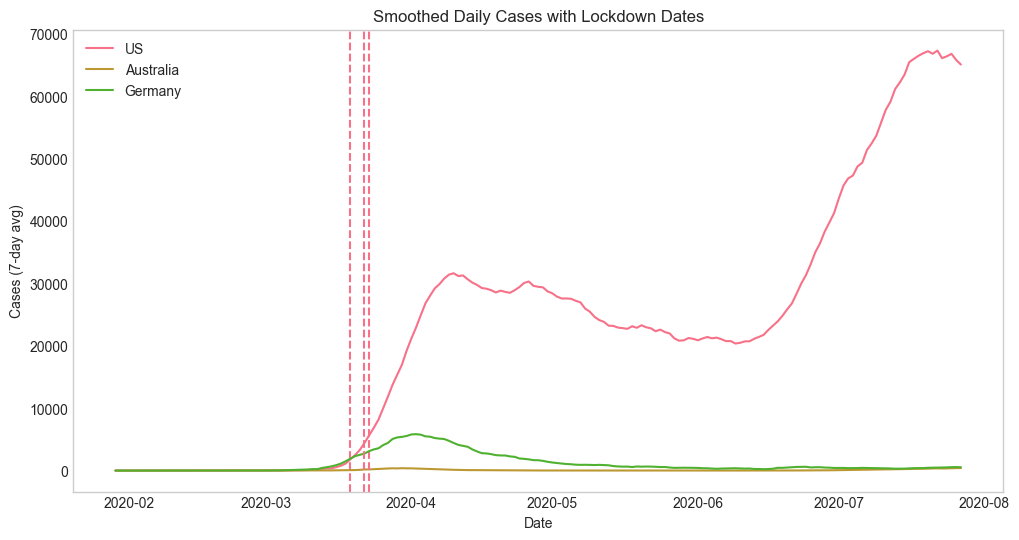

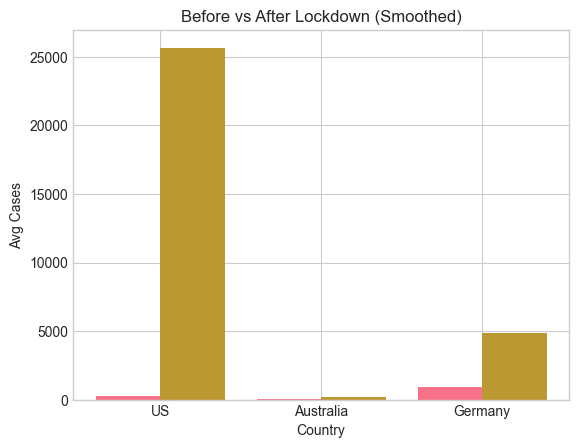

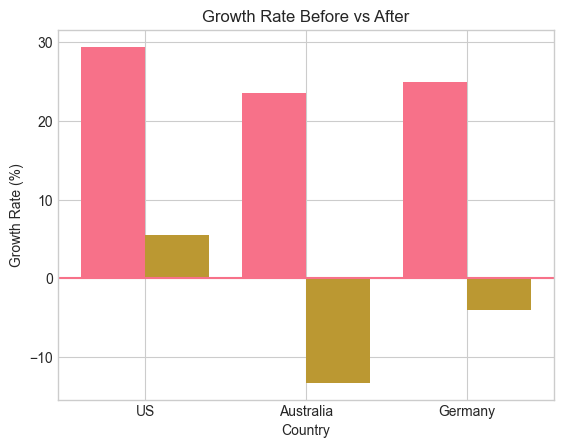

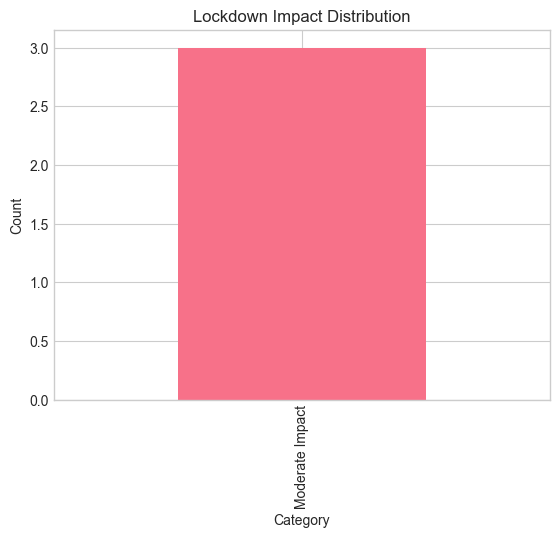

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("LOCKDOWN EFFECTIVENESS ANALYSIS (FINAL)")
print("=" * 60)

lockdown_dates = {
    'US': '2020-03-19',
    'Australia': '2020-03-23',
    'Germany': '2020-03-22'
}

lag_days = 10

# -----------------------------
# Data Preparation
# -----------------------------
def prepare_country_data(df, country):
    temp = df[df['Country/Region'] == country].copy()
    temp['date'] = pd.to_datetime(temp['Date'])
    temp = temp.groupby('date')[['Confirmed']].sum()

    temp['Daily Cases'] = temp['Confirmed'].diff()
    temp['Smoothed'] = temp['Daily Cases'].rolling(7).mean()

    return temp.dropna()

def compute_growth_rate(series):
    series = series[series > 0]
    if len(series) < 5:
        return None
    x = np.arange(len(series))
    y = np.log(series)
    slope = np.polyfit(x, y, 1)[0]
    return slope * 100

# -----------------------------
# Prepare data
# -----------------------------
usa = prepare_country_data(df, 'US')
aus = prepare_country_data(df, 'Australia')
ger = prepare_country_data(df, 'Germany')

countries_data = {
    'US': usa,
    'Australia': aus,
    'Germany': ger
}

results = []

# -----------------------------
# Analysis
# -----------------------------
for country, data in countries_data.items():

    lockdown_date = pd.to_datetime(lockdown_dates[country])

    before = data[data.index < lockdown_date]['Smoothed'].tail(14)
    after = data[data.index >= lockdown_date + pd.Timedelta(days=lag_days)]['Smoothed'].head(14)

    before_mean = before.mean()
    after_mean = after.mean()

    growth_before = compute_growth_rate(before)
    growth_after = compute_growth_rate(after)

    # ✅ Improved classification
    if pd.isna(before_mean) or pd.isna(after_mean):
        classification = "Insufficient Data"

    elif growth_after is not None and growth_before is not None:
        if growth_after < 0 and after_mean < before_mean:
            classification = "Strong Impact"
        elif growth_after < growth_before:
            classification = "Moderate Impact"
        else:
            classification = "Weak/No Impact"
    else:
        classification = "Unclear"

    results.append({
        'Country': country,
        'Before Avg': round(before_mean, 2),
        'After Avg': round(after_mean, 2),
        'Growth Before (%)': round(growth_before, 2) if growth_before else 'N/A',
        'Growth After (%)': round(growth_after, 2) if growth_after else 'N/A',
        'Classification': classification
    })

# -----------------------------
# Results Table
# -----------------------------
result_df = pd.DataFrame(results)
print("\n--- Final Classification ---")
print(result_df.to_string(index=False))

# -----------------------------
# 📊 GRAPH 1: Time Series (BEST GRAPH)
# -----------------------------
plt.figure(figsize=(12, 6))

for country, data in countries_data.items():
    plt.plot(data.index, data['Smoothed'], label=country)

    lockdown_date = pd.to_datetime(lockdown_dates[country])
    plt.axvline(lockdown_date, linestyle='--')

plt.title("Smoothed Daily Cases with Lockdown Dates")
plt.xlabel("Date")
plt.ylabel("Cases (7-day avg)")
plt.legend()
plt.grid()

plt.show()

# -----------------------------
# 📊 GRAPH 2: Before vs After
# -----------------------------
countries = result_df['Country']
before_vals = result_df['Before Avg']
after_vals = result_df['After Avg']

x = np.arange(len(countries))

plt.figure()
plt.bar(x - 0.2, before_vals, 0.4)
plt.bar(x + 0.2, after_vals, 0.4)

plt.xticks(x, countries)
plt.title("Before vs After Lockdown (Smoothed)")
plt.xlabel("Country")
plt.ylabel("Avg Cases")

plt.show()

# -----------------------------
# 📊 GRAPH 3: Growth Rate Comparison
# -----------------------------
growth_before = [r['Growth Before (%)'] if isinstance(r['Growth Before (%)'], float) else 0 for r in results]
growth_after = [r['Growth After (%)'] if isinstance(r['Growth After (%)'], float) else 0 for r in results]

plt.figure()
plt.bar(x - 0.2, growth_before, 0.4)
plt.bar(x + 0.2, growth_after, 0.4)

plt.xticks(x, countries)
plt.title("Growth Rate Before vs After")
plt.xlabel("Country")
plt.ylabel("Growth Rate (%)")
plt.axhline(0)

plt.show()

# -----------------------------
# 📊 GRAPH 4: Classification Count
# -----------------------------
result_df['Classification'].value_counts().plot(kind='bar')

plt.title("Lockdown Impact Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()